In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from useful_functions_global import *
from plotting_functions import *
import glob
from pathlib import Path
import simple_adl.simple_adl.coordinate_tools as coordinate_tools
import simple_adl.simple_adl.isochrone as isochrone
import healsparse as hsp
import healpy as hp
import skyproj

my_path =  '/sdf/data/rubin/user/kexcel/'
my_plotspath = my_path + 'plots/'
euclid_blue = 'xkcd:cornflower blue'

# Load in catalogs

In [2]:
survey = 'dp2'

files = Path('.').glob(f'euclid_data/q1/*_{survey}_euclid_merged.parquet')
ecdfs_list = []
edfs_list = []
for file in files:
    with open(file, 'rb') as f:
        df = pd.read_parquet(f, engine='fastparquet')
    file = str(file)
    parquet = file[(file.rfind('/')+1):]
    tract = int(parquet[0:parquet.find('_')])
    field = get_field(tract)
    if field == 'EDFS':
        edfs_list.append(df)
    elif field == 'ECDFS':
        ecdfs_list.append(df)
ecdfs = pd.concat(ecdfs_list, ignore_index=True)
edfs = pd.concat(edfs_list, ignore_index=True)

In [3]:
edfs.columns

Index(['coord_ra', 'coord_dec', 'detect_isIsolated', 'refExtendedness',
       'tract', 'patch', 'griz_model_extendedness', 'g_psfFlux',
       'g_cModelFlux', 'g_cModelFluxErr', 'g_psfFluxErr', 'g_extendedness',
       'g_extendedness_flag', 'g_psfFlux_flag', 'g_model_extendedness',
       'r_psfFlux', 'r_cModelFlux', 'r_cModelFluxErr', 'r_psfFluxErr',
       'r_extendedness', 'r_extendedness_flag', 'r_psfFlux_flag',
       'r_model_extendedness', 'i_psfFlux', 'i_cModelFlux', 'i_cModelFluxErr',
       'i_psfFluxErr', 'i_extendedness', 'i_extendedness_flag',
       'i_psfFlux_flag', 'i_model_extendedness', 'z_psfFlux', 'z_cModelFlux',
       'z_cModelFluxErr', 'z_psfFluxErr', 'z_extendedness',
       'z_extendedness_flag', 'z_psfFlux_flag', 'z_model_extendedness',
       'y_psfFlux', 'y_cModelFlux', 'y_cModelFluxErr', 'y_psfFluxErr',
       'y_extendedness', 'y_extendedness_flag', 'y_psfFlux_flag',
       'y_model_extendedness', 'RIGHT_ASCENSION', 'DECLINATION',
       'FLUX_VIS_2FWHM_

## Spatial coord maps

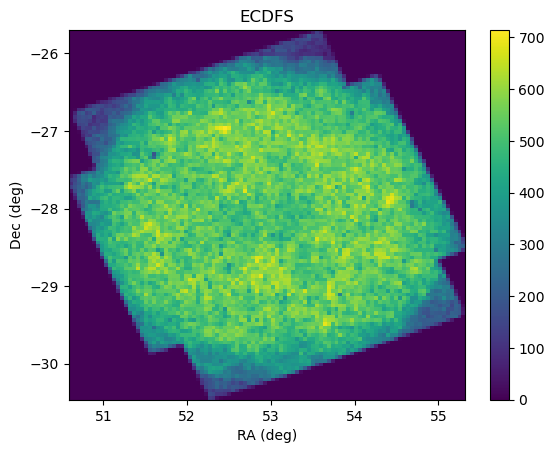

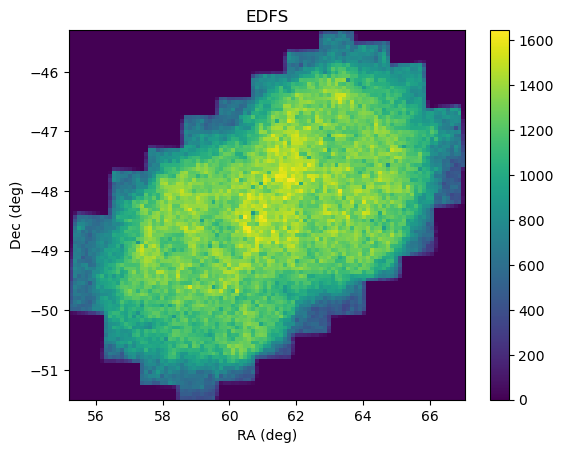

In [4]:
_, _, _, im = plt.hist2d(ecdfs['coord_ra'], ecdfs['coord_dec'], bins=100)
plt.colorbar(im)
plt.title('ECDFS')
plt.ylabel("Dec (deg)")
plt.xlabel("RA (deg)")
plt.savefig(my_plotspath+'/spatial_coordinates/dp2_ecdfs_precleaning.png')
plt.show()
_, _, _, im = plt.hist2d(edfs['coord_ra'], edfs['coord_dec'], bins=100)
plt.colorbar(im)
plt.title('EDFS')
plt.ylabel("Dec (deg)")
plt.xlabel("RA (deg)")
plt.savefig(my_plotspath+'/spatial_coordinates/dp2_edfs_precleaning.png')
plt.show()

## Define class

In [5]:
class DataFrame():
    def __init__(self, survey, data, field, qual_cuts_dict={}):
        self.survey = survey
        self.data = data
        self.field = field
        self.quality_cuts = qual_cuts_dict
        
        ## coordinates
        self.ra_limits = (data['coord_ra'].min(), data['coord_ra'].max())
        self.dec_limits = (data['coord_dec'].min(), data['coord_dec'].max())
        self.rubin_ra = data['coord_ra']
        self.rubin_dec = data['coord_dec']
        self.euclid_ra = data['RIGHT_ASCENSION']
        self.euclid_dec = data['DECLINATION']

        ## Euclid bands (flux given in mu_Jy)
        num = 2 #as suggested in Zerjal et al
        self.H_mag = flux2mag(data[f'FLUX_H_{num}FWHM_APER']*(10**3)) #convert to nJy
        self.Y_mag = flux2mag(data[f'FLUX_Y_{num}FWHM_APER']*(10**3)) #convert to nJy
        self.J_mag = flux2mag(data[f'FLUX_J_{num}FWHM_APER']*(10**3)) #convert to nJy
        self.H_magerr = fluxerr2magerr(self.H_mag, flux2mag(data[f'FLUXERR_H_{num}FWHM_APER']*(10**3)))
        self.Y_magerr = fluxerr2magerr(self.Y_mag, flux2mag(data[f'FLUXERR_Y_{num}FWHM_APER']*(10**3)))
        self.J_magerr = fluxerr2magerr(self.J_mag, flux2mag(data[f'FLUXERR_J_{num}FWHM_APER']*(10**3)))

        ## Rubin bands
        self.g_mag = flux2mag(data['g_psfFlux'])
        self.r_mag = flux2mag(data['r_psfFlux'])
        self.i_mag = flux2mag(data['i_psfFlux'])
        self.z_mag = flux2mag(data['z_psfFlux'])
        self.g_magerr = fluxerr2magerr(self.g_mag, flux2mag(data['g_psfFluxErr']))
        self.r_magerr = fluxerr2magerr(self.r_mag, flux2mag(data['r_psfFluxErr']))
        self.i_magerr = fluxerr2magerr(self.i_mag, flux2mag(data['i_psfFluxErr']))
        self.z_magerr = fluxerr2magerr(self.z_mag, flux2mag(data['z_psfFluxErr']))

        self.pointlikeprob = data['POINT_LIKE_PROB']
        self.ellipticity = data['ELLIPTICITY']
        self.mumax_minus_mag = self.data['MUMAX_MINUS_MAG']

    def Zerjal_cut(self):
        stars_mask = (self.ellipticity < 0.2) 
        stars_mask &= (self.mumax_minus_mag< -2.7) & (self.mumax_minus_mag> -3.25)
        return stars_mask, self.apply_mask(stars_mask)

    def POINT_LIKE_PROB_cut(self, threshold):
        stars_mask = (self.pointlikeprob > threshold)
        return stars_mask, self.apply_mask(stars_mask)

    def POINT_LIKE_FLAG_cut(self):
        stars_mask = (self.data['POINT_LIKE_FLAG'] == 1)
        return stars_mask, self.apply_mask(stars_mask)

    def apply_mask(self, mask):
        ## takes in a mask, applies it to the df, then returns another DataFrame object
        new_data = self.data[mask]
        return DataFrame(self.survey, new_data, self.field, self.quality_cuts)
        
    def clean_data(self, lsst_bands, euclid_bands, lsst_sn_bands, euclid_sn_bands, snr=5, flags = True, det_qual_flags = [0, 2]):
        '''
        inputs
        --------
        lsst_bands : str, bands (from ugrizy) in which to enforce quality flags
        euclid_bands : list of str, bands (from VIS, Y, J, H) in which to enforce quality flags
        lsst_sn_bands : str, bands (from ugrizy) in which to enforce source to noise cuts
        euclid_sn_bands : list of str, bands (from VIS, Y, J, H) in which to enforce source to noise cuts
        snr : the source to noise ratio you want to enforce

        returns
        --------
        new DataFrame object but with the cuts applied and an updated dictionary to keep track
        '''
        df = self.data
        ## 1. flags
        if flags == True:
            mask = (df['detect_isIsolated'] == True) #lsst
            mask &= (df['SPURIOUS_FLAG'] == 0) #euclid
            det_qual_mask = (df['DET_QUALITY_FLAG'] == 0)
            for i in det_qual_flags:
                if i == 0:
                    pass
                else:
                    det_qual_mask |= (df['DET_QUALITY_FLAG'] == i)
            mask &= det_qual_mask
        ## 2. per band S/N
        for band in lsst_sn_bands:
            mask &= (df[f'{band}_psfFlux']/df[f'{band}_psfFluxErr'] > snr)
        for band in euclid_sn_bands:
                #if band == 'VIS':
            #    mask &= (merged_df[f'FLUX_VIS_PSF']/merged_df[f'FLUXERR_VIS_PSF'] > snr)
            #else:
            ## I actually don't know which one to use for VIS
            num = 2
            mask &= (df[f'FLUX_{band}_{num}FWHM_APER']/df[f'FLUXERR_{band}_{num}FWHM_APER'] > snr)
        ## 3. per band flag
        for band in lsst_bands:
            mask &= (df[f'{band}_psfFlux_flag'] == 0)
            
        ## see https://euclid.esac.esa.int/dr/q1/dpdd/merdpd/merphotometrycookbook.html abt which flags to enforce
        #for band in euclid_bands:
        #    mask &= (merged_df[f'FLAG_{band}']==0)
        
        ## 4. enforcing that euclid sources having FWHM above 1.5" is spurious (Zerjal et al. suggestion)
        f = 1.5
        mask &= (df['FWHM'] <= f)

        ## updates the quality_cuts attribute along the way, so I can keep track of these things
        cut_dict = {'detect_isIsolated' : True, 'SPURIOUS_FLAG' : 0, 'DET_QUALITY_FLAG' : det_qual_flags, 
                    'LSST S/N' : f'{lsst_sn_bands} > {snr} ', 'Euclid S/N' : f'{euclid_sn_bands} > {snr} ', 
                    'LSST per band flag' : lsst_bands, 'FWHM' : f}
        if len(self.quality_cuts.keys()) != 0:
            for key in self.quality_cuts.keys():
                cut_dict[key] = cut_dict[key] + self.quality_cuts[key]

        return DataFrame(self.survey, df[mask], self.field, cut_dict)

#### Euclid stars and Rubin classifiers as supplied as functions here
idk what will be more useful in the long run

In [6]:
def euclid_stars_mask(data, method):
    if 'POINT_LIKE_PROB' in method:
        number = float(method[-3:])
        print(number)
        return (data['POINT_LIKE_PROB']>number)
    elif method == 'POINT_LIKE_FLAG':
        return (data['POINT_LIKE_FLAG']==1)
    elif method == 'Zerjal':
        return (data['ELLIPTICITY'] < 0.2) & (data['MUMAX_MINUS_MAG']< -2.65) & (data['MUMAX_MINUS_MAG']> -3.25)

def flux_ratio(df, band):
    return df[f'{band}_psfFlux'] / df[f'{band}_cModelFlux']
def flux_ratio_err(df, band):
    return np.sqrt((df[f'{band}_psfFluxErr']/df[f'{band}_cModelFlux'])**2
                   + ((df[f'{band}_psfFlux']/df[f'{band}_cModelFlux']**2)*df[f'{band}_cModelFluxErr'])**2)
def flux_ratio_classifier(c, df, band):
    '''
    Alex Drlica-Wagner suggested 
        (1- refFluxRatio)+5/2*refFluxRatioErr 
    as something that worked for DES. 
    Generalized here (5/2 now just general 'c')
    '''
    return (1 - flux_ratio(df, band)) + c*flux_ratio_err(df, band)
def rubin_morphology(df, band):
    return flux2mag(df[f'{band}_psfFlux']) - flux2mag(df[f'{band}_cModelFlux'])
def rubin_morphology_err(df,band):
    return np.sqrt(fluxerr2magerr(df[f'{band}_psfFlux'],df[f'{band}_psfFluxErr'])**2 
                   + fluxerr2magerr(df[f'{band}_cModelFlux'],df[f'{band}_cModelFluxErr'])**2)
def combine_bandext_info(df, operation):
    ## not going to use g info because it's decidedly worse as seen in ROC curve
    if operation == '*':
        return df['r_model_extendedness']*df['i_model_extendedness']*df['z_model_extendedness']

## define which field here

In [7]:
EDFS = DataFrame('dp2',edfs,'EDFS')
ECDFS = DataFrame('dp2',ecdfs,'ECDFS')

In [8]:
ECDFS_cleaned = ECDFS.clean_data('griz', ['VIS','Y','J','H'], 'r', ['VIS'], snr = 5, det_qual_flags = [0, 2, 512])
EDFS_cleaned = EDFS.clean_data('griz', ['VIS','Y','J','H'], 'r', ['VIS'], snr = 5, det_qual_flags = [0, 2, 512])

EDFS_cleaned.quality_cuts

{'detect_isIsolated': True,
 'SPURIOUS_FLAG': 0,
 'DET_QUALITY_FLAG': [0, 2, 512],
 'LSST S/N': 'r > 5 ',
 'Euclid S/N': "['VIS'] > 5 ",
 'LSST per band flag': 'griz',
 'FWHM': 1.5}

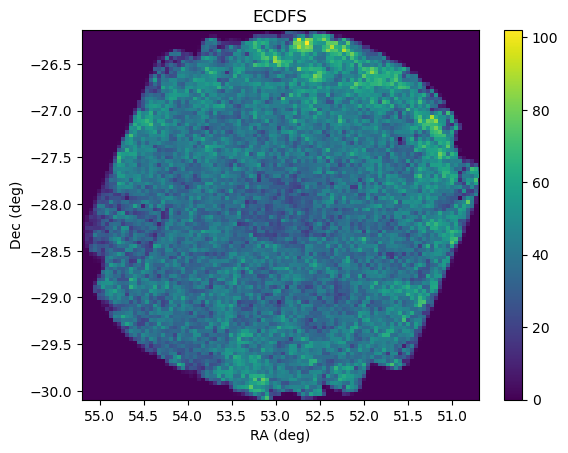

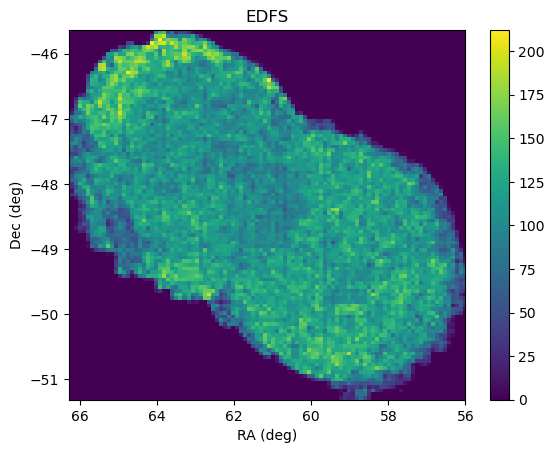

In [9]:
_, _, _, im = plt.hist2d(ECDFS_cleaned.rubin_ra, ECDFS_cleaned.rubin_dec, bins=100)
plt.colorbar(im)
plt.title('ECDFS')
plt.ylabel("Dec (deg)")
plt.xlabel("RA (deg)")
plt.xlim(55.2, 50.7)
plt.savefig(my_plotspath+'/spatial_coordinates/dp2_ecdfs_postcleaning.png')
plt.show()
_, _, _, im = plt.hist2d(EDFS_cleaned.rubin_ra, EDFS_cleaned.rubin_dec, bins=100)
plt.colorbar(im)
plt.title('EDFS')
plt.ylabel("Dec (deg)")
plt.xlabel("RA (deg)")
plt.xlim(66.3, 56)
plt.savefig(my_plotspath+'/spatial_coordinates/dp2_edfs_postcleaning.png')
plt.show()

In [10]:
for col in ECDFS.data.columns:
    if 'extendedness' in col.lower():
        print(col)

refExtendedness
griz_model_extendedness
g_extendedness
g_extendedness_flag
g_model_extendedness
r_extendedness
r_extendedness_flag
r_model_extendedness
i_extendedness
i_extendedness_flag
i_model_extendedness
z_extendedness
z_extendedness_flag
z_model_extendedness
y_extendedness
y_extendedness_flag
y_model_extendedness


# Plotting

296926


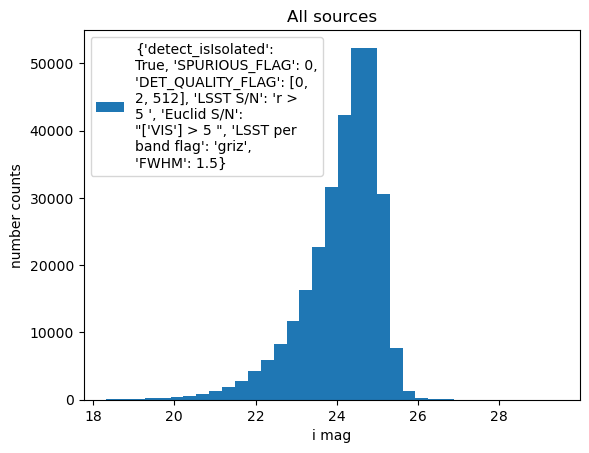

295486


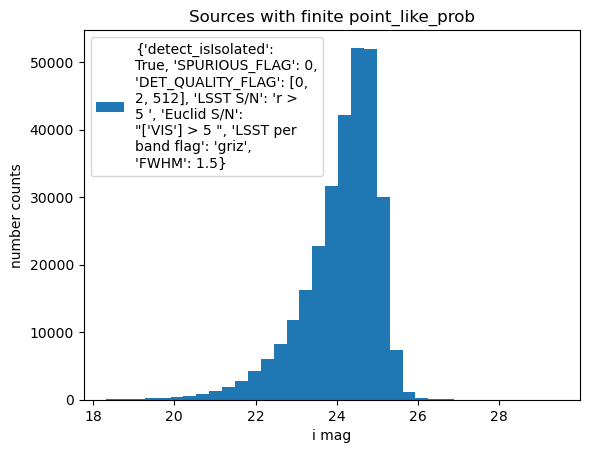

In [11]:
from textwrap import fill
plt.hist(ECDFS_cleaned.i_mag, bins=35, label = fill(str(ECDFS_cleaned.quality_cuts), width = 25))
print(len(ECDFS_cleaned.i_mag))
plt.xlabel('i mag')
plt.ylabel('number counts')
plt.legend()
plt.title('All sources')
plt.show()

plt.hist(ECDFS_cleaned.i_mag[np.isfinite(ECDFS_cleaned.pointlikeprob)], bins=35, label = fill(str(ECDFS_cleaned.quality_cuts), width = 25))
print(len(ECDFS_cleaned.i_mag[np.isfinite(ECDFS_cleaned.pointlikeprob)]))
plt.xlabel('i mag')
plt.ylabel('number counts')
plt.legend()
plt.title('Sources with finite point_like_prob')
plt.show()

In [12]:
100*len(ECDFS_cleaned.H_mag[~np.isfinite(ECDFS_cleaned.H_mag)]) / len(ECDFS_cleaned.H_mag)

0.45297481527383926

In [13]:
100 - 100*len(ECDFS_cleaned.H_mag[(ECDFS_cleaned.H_mag/ECDFS_cleaned.H_magerr > 5)]) / len(ECDFS_cleaned.H_mag)

0.45297481527383354

## Morphology in Rubin and Euclid

In [14]:
DF = ECDFS_cleaned
ECDFS_cleaned.quality_cuts

{'detect_isIsolated': True,
 'SPURIOUS_FLAG': 0,
 'DET_QUALITY_FLAG': [0, 2, 512],
 'LSST S/N': 'r > 5 ',
 'Euclid S/N': "['VIS'] > 5 ",
 'LSST per band flag': 'griz',
 'FWHM': 1.5}

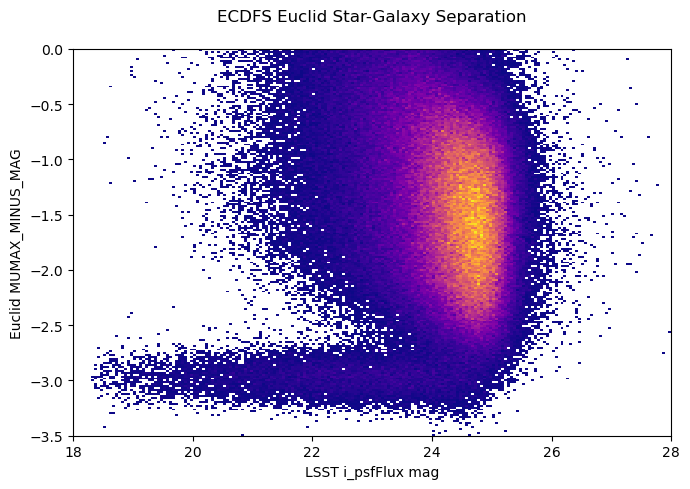

In [15]:
star_gal_sep(DF.data, 'MUMAX_MINUS_MAG', 
             None, None, 
             '_nolegend', 
             f'{DF.field} Euclid Star-Galaxy Separation', colors = 'plasma',
             histogram = True,
             y_lim=(-3.5, 0),
             save=True, plots_path=my_plotspath, 
             filename = f'euclidmorph_all_{DF.field.lower()}_{DF.survey.lower()}')

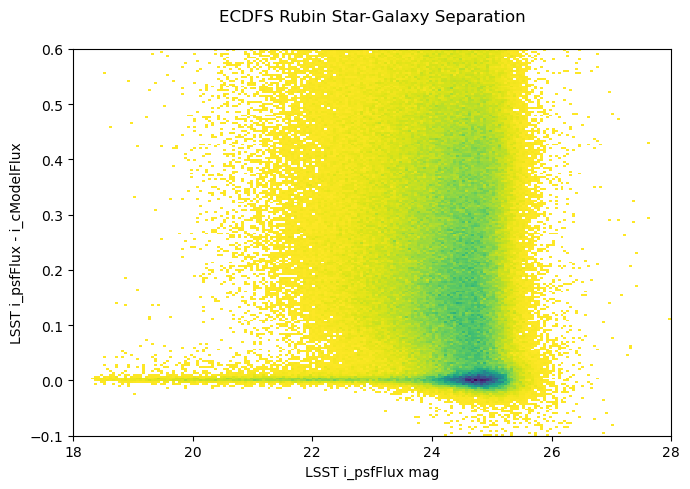

In [16]:
star_gal_sep(DF.data, 'i psf - cmodel',
             None, None, '_nolegend', 
             f'{DF.field} Rubin Star-Galaxy Separation', 
             histogram = True,
             save=True, plots_path=my_plotspath, 
             filename = f'rubinmorph_all_{DF.field.lower()}_{DF.survey.lower()}')

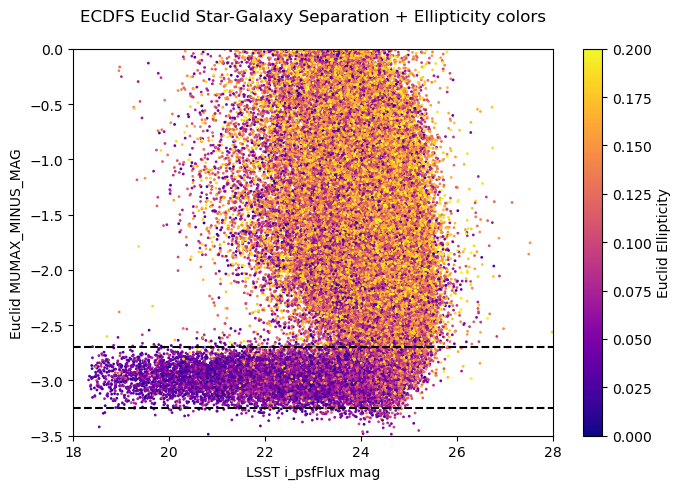

In [17]:
no_ellipDF = DF.apply_mask((DF.ellipticity < 0.2))
star_gal_sep(no_ellipDF.data, 'MUMAX_MINUS_MAG', 
             no_ellipDF.ellipticity, 'Euclid Ellipticity', 
             '_nolegend', 
             f'{no_ellipDF.field} Euclid Star-Galaxy Separation + Ellipticity colors', 
             histogram = False, colors = 'plasma',
             colorbar_limits=(0, 0.2), y_lim=(-3.5, 0), x_lim=(18,28))
x=np.linspace(18,28)
plt.plot(x, np.linspace(-3.25, -3.25),'k--')
plt.plot(x, np.linspace(-2.7, -2.7),'k--')
plt.savefig(my_plotspath +
        f'stargalsep/euclidmorph_ellipticitycut_{DF.field.lower()}_{DF.survey.lower()}')

/sdf/data/rubin/user/kexcel/plotting_functions.py:325: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


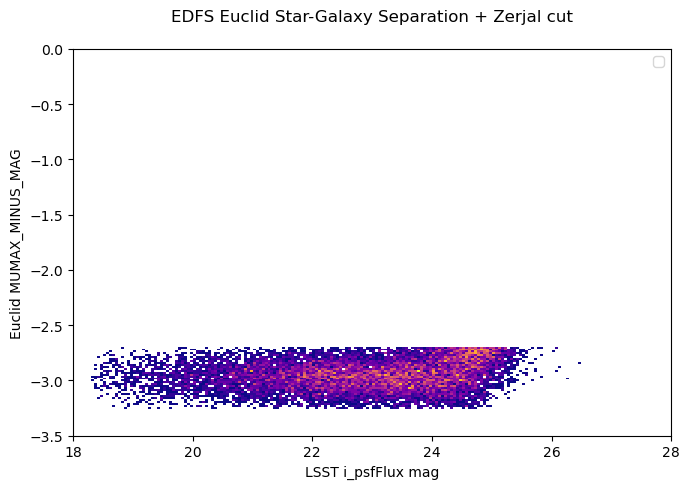

In [18]:
star_gal_sep(DF.Zerjal_cut()[1].data, 'MUMAX_MINUS_MAG', 
             None, None, 
             '(ELLPTICITY < 0.2) & (-3.25 < MUMAX_MINUS_MAG < -2.7)', 
             f'{field} Euclid Star-Galaxy Separation + Zerjal cut', 
             histogram = True, colors = 'plasma',
             colorbar_limits=(0.4, 1), y_lim=(-3.5, 0), x_lim=(18,28),
             save=True, plots_path=my_plotspath, 
             filename = f'euclidmorph_zerjalcut_{DF.field.lower()}_{DF.survey.lower()}')

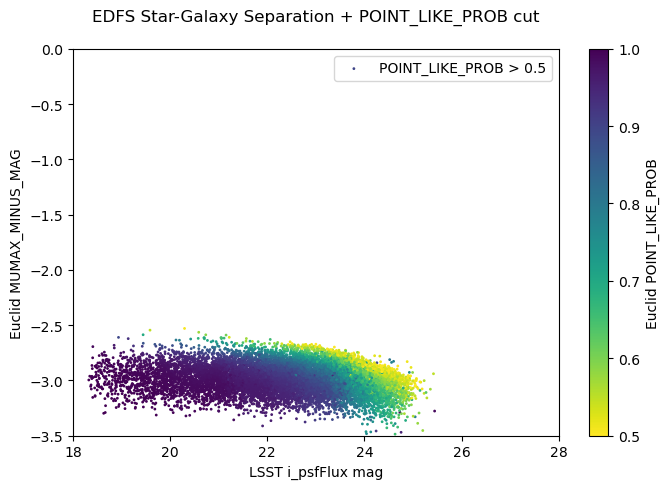

In [19]:
star_gal_sep(DF.POINT_LIKE_PROB_cut(0.5)[1].data, 'MUMAX_MINUS_MAG',
             DF.POINT_LIKE_PROB_cut(0.5)[1].data['POINT_LIKE_PROB'], 'Euclid POINT_LIKE_PROB',
             'POINT_LIKE_PROB > 0.5',
             f'{field} Star-Galaxy Separation + POINT_LIKE_PROB cut',
             colorbar_limits=(0.5, 1), y_lim=(-3.5, 0), x_lim=(18,28),
             save=True, plots_path=my_plotspath, 
             filename = f'euclidmorph_pointlike0.5cut_{DF.field.lower()}_{DF.survey.lower()}')

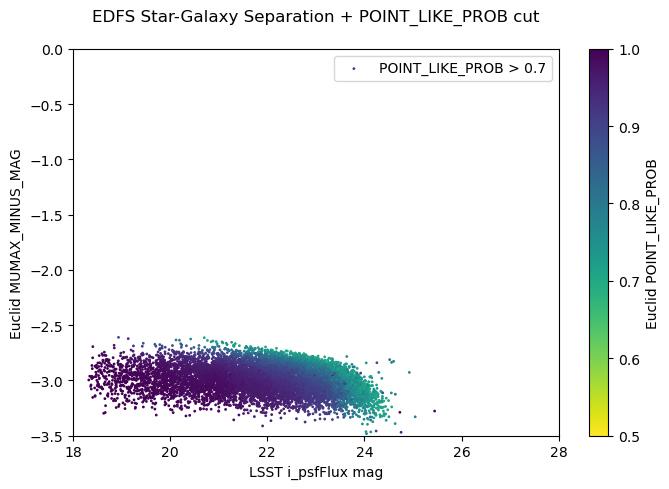

In [20]:
star_gal_sep(DF.POINT_LIKE_PROB_cut(0.7)[1].data, 'MUMAX_MINUS_MAG',
             DF.POINT_LIKE_PROB_cut(0.7)[1].data['POINT_LIKE_PROB'], 'Euclid POINT_LIKE_PROB',
             'POINT_LIKE_PROB > 0.7',
             f'{field} Star-Galaxy Separation + POINT_LIKE_PROB cut',
             colorbar_limits=(0.5, 1), y_lim=(-3.5, 0), x_lim=(18,28),
             save=True, plots_path=my_plotspath, 
             filename = f'euclidmorph_pointlike0.7cut_{DF.field.lower()}_{DF.survey.lower()}')

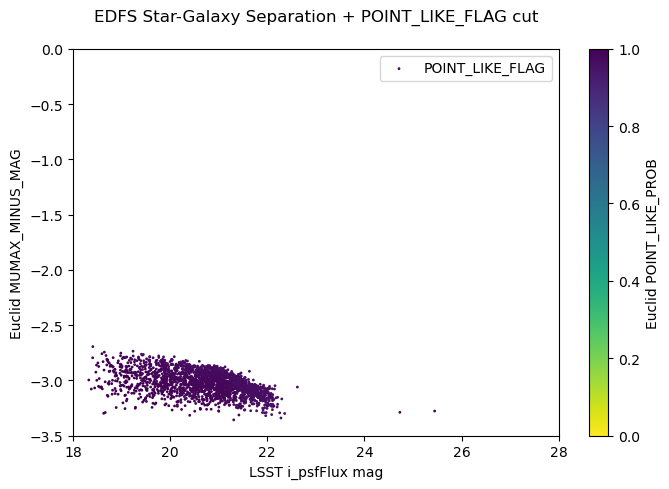

In [21]:
star_gal_sep(DF.POINT_LIKE_FLAG_cut()[1].data, 'MUMAX_MINUS_MAG',
             DF.POINT_LIKE_FLAG_cut()[1].data['POINT_LIKE_PROB'], 'Euclid POINT_LIKE_PROB',
             'POINT_LIKE_FLAG',
             f'{field} Star-Galaxy Separation + POINT_LIKE_FLAG cut',
             colorbar_limits=(0, 1), y_lim=(-3.5, 0), x_lim=(18,28),
             save=True, plots_path=my_plotspath, 
             filename =f'euclidmorph_pointlikeflagcut_{field.lower()}_{DF.survey.lower()}')

## Color-Color Stellar Locus -> Morphology

In [22]:
print(EDFS_cleaned.quality_cuts)
print(ECDFS_cleaned.quality_cuts)

{'detect_isIsolated': True, 'SPURIOUS_FLAG': 0, 'DET_QUALITY_FLAG': [0, 2, 512], 'LSST S/N': 'r > 5 ', 'Euclid S/N': "['VIS'] > 5 ", 'LSST per band flag': 'griz', 'FWHM': 1.5}
{'detect_isIsolated': True, 'SPURIOUS_FLAG': 0, 'DET_QUALITY_FLAG': [0, 2, 512], 'LSST S/N': 'r > 5 ', 'Euclid S/N': "['VIS'] > 5 ", 'LSST per band flag': 'griz', 'FWHM': 1.5}


/tmp/ipykernel_122/467324529.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(my_plotspath+filename)


/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.2.0-exact/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


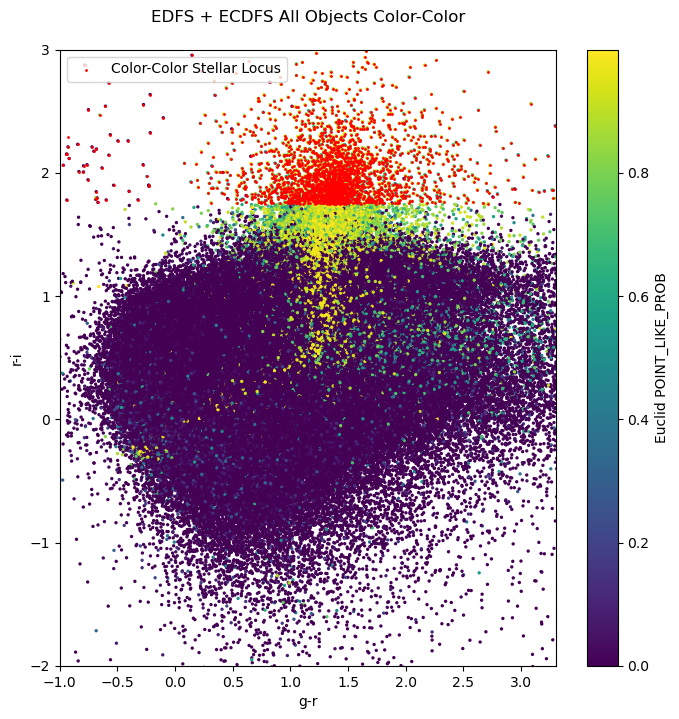

In [23]:
alltogethernow = DataFrame('dp2',pd.concat([EDFS_cleaned.data,ECDFS_cleaned.data]),'EDFS+ECDFS',[EDFS_cleaned.quality_cuts,ECDFS_cleaned.quality_cuts])

plt.figure(figsize=(8,8))
plt.scatter(alltogethernow.g_mag - alltogethernow.r_mag, alltogethernow.r_mag - alltogethernow.i_mag,
            c=alltogethernow.data['POINT_LIKE_PROB'], s=2)
#plt.scatter(ECDFS_cleaned.g_mag - ECDFS_cleaned.r_mag, ECDFS_cleaned.r_mag - ECDFS_cleaned.i_mag,
#            c=ECDFS_cleaned.data['POINT_LIKE_PROB'], s=2)
plt.colorbar(label='Euclid POINT_LIKE_PROB')


def color_color_stars_mask(DF): return (DF.r_mag - DF.i_mag > 1.75) #& (g_mag-r_mag > 0.5) & (g_mag-r_mag < 3) & (r_mag - i_mag < 3)

alltogether_cc_cut = alltogethernow.apply_mask(color_color_stars_mask(alltogethernow))
#ECDFS_cc_cut = ECDFS_cleaned.apply_mask(color_color_stars_mask(ECDFS_cleaned))


stellar_locus = True

if stellar_locus==True:
    plt.scatter(alltogether_cc_cut.g_mag - alltogether_cc_cut.r_mag,
                alltogether_cc_cut.r_mag - alltogether_cc_cut.i_mag,
                c='r', s=size,
                label ='Color-Color Stellar Locus')
    #plt.scatter(ECDFS_cc_cut.g_mag - ECDFS_cc_cut.r_mag,
    #            ECDFS_cc_cut.r_mag - ECDFS_cc_cut.i_mag,
    #            c='r', s=size,
    #            )
    plt.legend()
    filename = '/colorcolor/stellar_locus_highlighted.png'
else:
    filename = '/colorcolor/stellar_locus_finding.png'
    
plt.title('EDFS + ECDFS All Objects Color-Color',pad=pad)
plt.xlim(-1,3.3)
plt.ylim(-2,3)
plt.xlabel('g-r')
plt.ylabel('r-i')
plt.savefig(my_plotspath+filename)

/sdf/data/rubin/user/kexcel/plotting_functions.py:325: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipykernel_122/4063881771.py:9: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


/sdf/data/rubin/user/kexcel/plotting_functions.py:325: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


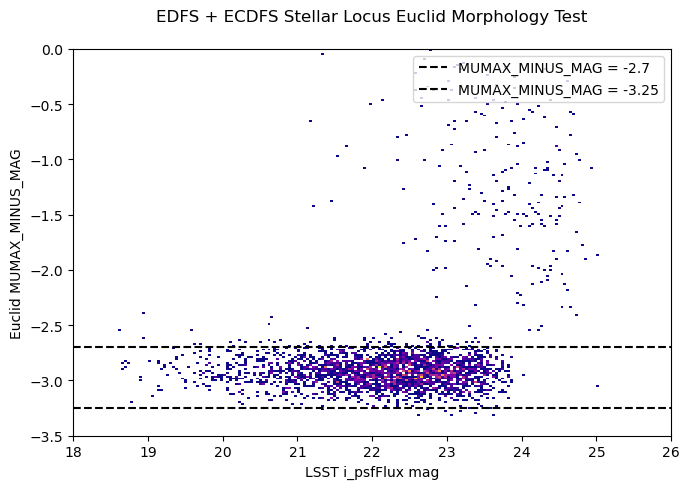

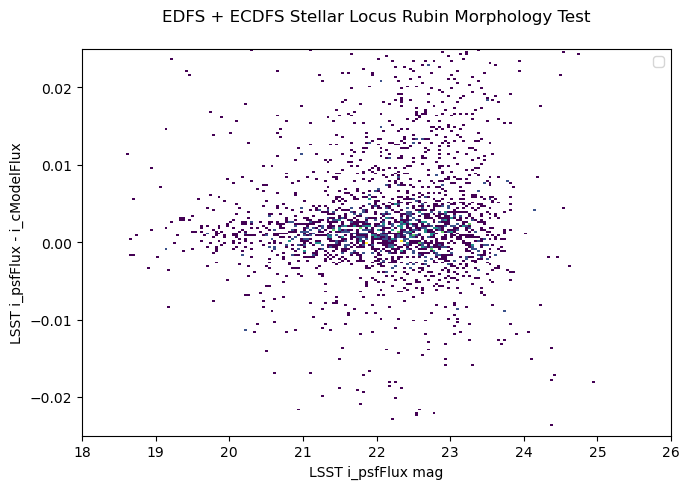

In [24]:
star_gal_sep(alltogether_cc_cut.data, 'MUMAX_MINUS_MAG', 
             None, None,
             '(r_mag - i_mag > 1.75)', 
             f'EDFS + ECDFS Stellar Locus Euclid Morphology Test', histogram = True,
             colors = 'plasma',
             y_lim=(-3.5, 0), x_lim=(18,26))
plt.plot(np.linspace(18,28,10),np.linspace(-2.7,-2.7,10),'k--', label='MUMAX_MINUS_MAG = -2.7')
plt.plot(np.linspace(18,28,10),np.linspace(-3.25,-3.25,10),'k--', label='MUMAX_MINUS_MAG = -3.25')
plt.legend()
plt.savefig(my_plotspath+'/stargalsep/stellarlocus_euclidmorph_edfs+ecdfs_dp2.png')

star_gal_sep(alltogether_cc_cut.data, 'i psf - cmodel', 
             None, None,
             '(r_mag - i_mag > 1.75)', 
             f'EDFS + ECDFS Stellar Locus Rubin Morphology Test', histogram = True,
             colors = 'viridis', y_lim = (-0.025, 0.025), x_lim = (18,26)
             )
#plt.plot(np.linspace(18,28,10),np.linspace(-2.7,-2.7,10),'k--', label='MUMAX_MINUS_MAG = -2.7')
#plt.plot(np.linspace(18,28,10),np.linspace(-3.25,-3.25,10),'k--', label='MUMAX_MINUS_MAG = -3.25')
#plt.legend()
plt.savefig(my_plotspath+'/stargalsep/stellarlocus_rubinmorph_edfs+ecdfs_dp2.png')

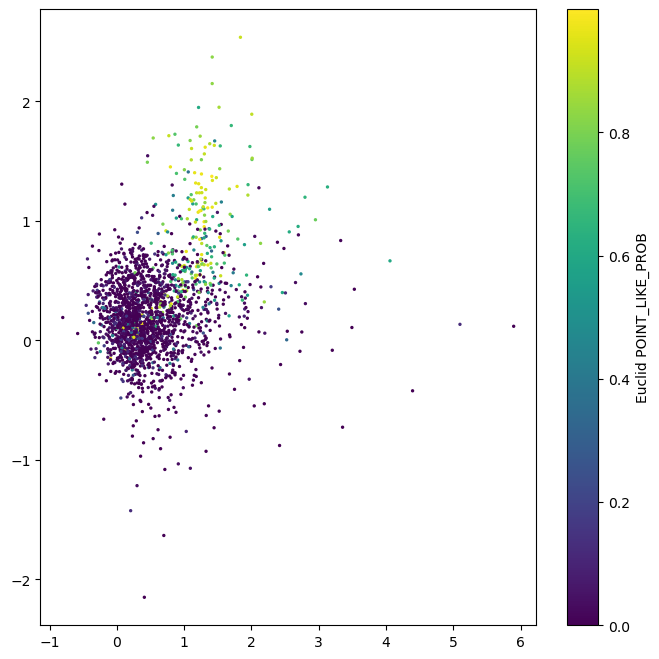

In [25]:
def rubin_morph_mask(DF): 
    mask1 = (DF.data['i_psfFlux'] - DF.data['i_cModelFlux'] < 0.1)
    mask2 = (DF.data['i_psfFlux'] - DF.data['i_cModelFlux'] > -0.1)
    return mask1 & mask2
morphin_time = alltogethernow.apply_mask(rubin_morph_mask(alltogethernow))
plt.figure(figsize=(8,8))
plt.scatter(morphin_time.g_mag - morphin_time.r_mag, morphin_time.r_mag - morphin_time.i_mag,
            c=morphin_time.data['POINT_LIKE_PROB'], s=2)
plt.colorbar(label='Euclid POINT_LIKE_PROB')

## ROC curve classifier evaluation

In [27]:
alltogethernow.quality_cuts

[{'detect_isIsolated': True,
  'SPURIOUS_FLAG': 0,
  'DET_QUALITY_FLAG': [0, 2, 512],
  'LSST S/N': 'r > 5 ',
  'Euclid S/N': "['VIS'] > 5 ",
  'LSST per band flag': 'griz',
  'FWHM': 1.5},
 {'detect_isIsolated': True,
  'SPURIOUS_FLAG': 0,
  'DET_QUALITY_FLAG': [0, 2, 512],
  'LSST S/N': 'r > 5 ',
  'Euclid S/N': "['VIS'] > 5 ",
  'LSST per band flag': 'griz',
  'FWHM': 1.5}]

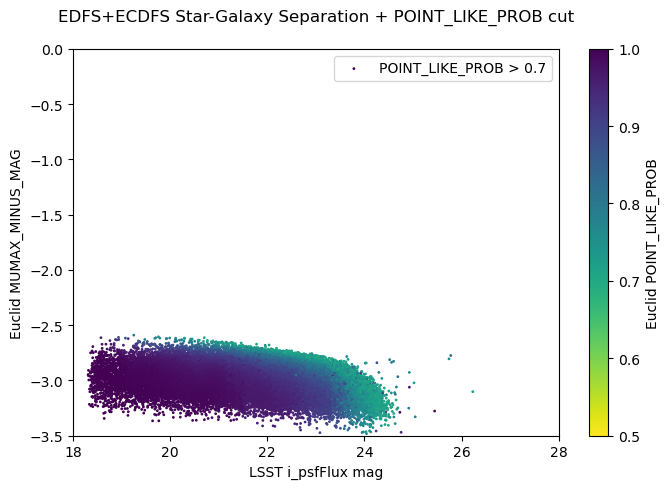

In [28]:
star_gal_sep(alltogethernow.POINT_LIKE_PROB_cut(0.7)[1].data, 'MUMAX_MINUS_MAG',
             alltogethernow.POINT_LIKE_PROB_cut(0.7)[1].data['POINT_LIKE_PROB'], 'Euclid POINT_LIKE_PROB',
             'POINT_LIKE_PROB > 0.7',
             f'{alltogethernow.field} Star-Galaxy Separation + POINT_LIKE_PROB cut',
             colorbar_limits=(0.5, 1), y_lim=(-3.5, 0), x_lim=(18,28),
             save=True, plots_path=my_plotspath, 
             filename = f'euclidmorph_pointlike0.7cut_{alltogethernow.field.lower()}_{alltogethernow.survey.lower()}')

In [29]:
maglim = 24.5
mag_validity_mask = (alltogethernow.i_mag<maglim)
allDF_magcut = alltogethernow.apply_mask(mag_validity_mask)
df = allDF_magcut.data

0.7
# of stars 41843.0
1-i_flux_ratio + 1.2*i_flux_ratio_err 0.9045991897583008


1-i_flux_ratio + 2.5*i_flux_ratio_err 0.846043586730957
g_model_extendedness 0.5200001001358032
r_model_extendedness 0.57834792137146


i_model_extendedness 0.6249218583106995
z_model_extendedness 0.5656331777572632
griz_model_extendedness 0.652173638343811
refExtendedness 1.0


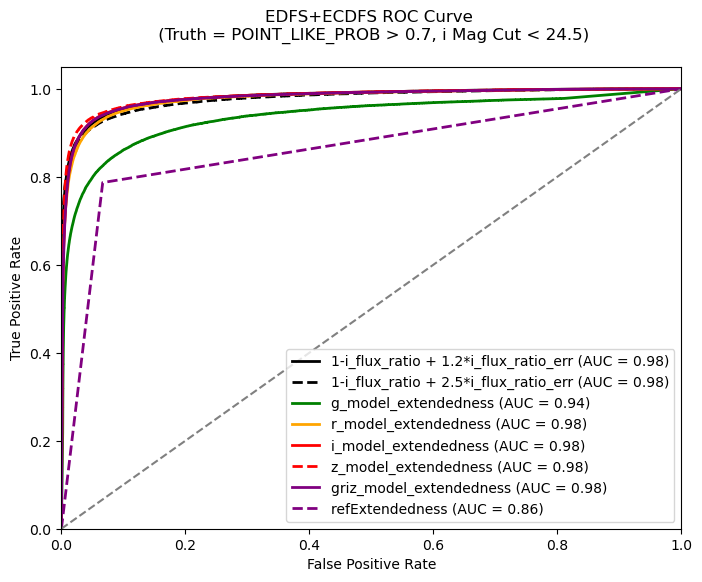

In [30]:
# build ROC curve
from sklearn.metrics import roc_curve, auc

# define the truth labels (star is true in this case)
cut = 0.7
euclid_truth = np.zeros_like(df['coord_ra'])
euclid_truth[euclid_stars_mask(df,f'POINT_LIKE_PROB > {cut}')] = 1
print('# of stars', np.sum(euclid_truth))

# define an array where the dictionaries with the classifiers will live
classifiers = [
    {"name":'1-i_flux_ratio + 1.2*i_flux_ratio_err','predicted':1-flux_ratio_classifier(1.2,df,'i'),'color':'black','linestyle':'solid'},
    {"name":'1-i_flux_ratio + 2.5*i_flux_ratio_err','predicted':1-flux_ratio_classifier(2.5,df,'i'),'color':'black','linestyle':'dashed'},
    {"name":'g_model_extendedness','predicted':1-df['g_model_extendedness'],'color':'green','linestyle':'solid'},
    {"name":'r_model_extendedness','predicted':1-df['r_model_extendedness'],'color':'orange','linestyle':'solid'},
    {"name":'i_model_extendedness','predicted':1-df['i_model_extendedness'],'color':'red','linestyle':'solid'},
    {"name":'z_model_extendedness','predicted':1-df['z_model_extendedness'],'color':'red','linestyle':'dashed'},
    {"name":'griz_model_extendedness','predicted':1-df['griz_model_extendedness'],'color':'purple','linestyle':'solid'},
    {"name":'refExtendedness','predicted':1-df['refExtendedness'],'color':'purple','linestyle':'dashed'}
    #{"name":'ML flux ratio classifier','predicted':(24.260 * df['i_flux_ratio'] + -30.032 * df['i_flux_ratio_err'] + -23.021),'color':'black','linestyle':'solid'},
    #{"name":'ML flux ratio classifier','predicted':(-20.165 * df['r_psfminuscmodel'] + -18.316 * df['r_psfminuscmodel_err'] + 0.876),'color':'brown','linestyle':'solid'}
]

plt.figure(figsize=(8,6))
for i in range(len(classifiers)):
    lsst_predicted = classifiers[i]['predicted']
    #drop NaNs appearing in the lsst class
    mask = lsst_predicted.notna()
    lsst_predicted_clean = lsst_predicted[mask]
    fpr, tpr, thresholds = roc_curve(euclid_truth[mask], lsst_predicted_clean)
    optimal_index = np.argmax(tpr - fpr)
    #plt.scatter(fpr[optimal_index], tpr[optimal_index], color=classifiers[i]['color'])
    print(classifiers[i]['name'], thresholds[optimal_index])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=classifiers[i]['color'], ls=classifiers[i]['linestyle'],
             lw=2, label=f'{classifiers[i]['name']} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # random chance line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'{allDF_magcut.field} ROC Curve \n (Truth = POINT_LIKE_PROB > {cut}, i Mag Cut < {maglim})',pad=pad)
plt.legend(loc="lower right")
plt.savefig(my_plotspath + f'ROC/pointlike{cut}truth_imag{str(maglim).replace('.','')}_{allDF_magcut.field.replace(' ','').lower()}_{allDF_magcut.survey.lower()}.png')
plt.show()

## Color-Color and Color-Magnitude of Euclid stars

In [31]:
onetractedfs = EDFS_cleaned.apply_mask((EDFS_cleaned.data['tract']== 2394)|(EDFS_cleaned.data['tract']== 2393)|(EDFS_cleaned.data['tract']== 2392))

### i_model_extendedness

{'detect_isIsolated': 2, 'SPURIOUS_FLAG': 0, 'DET_QUALITY_FLAG': [0, 2, 0, 2, 512], 'LSST S/N': 'g > 5 r > 5 ', 'Euclid S/N': "[] > 5 ['VIS'] > 5 ", 'LSST per band flag': 'griz', 'FWHM': 3.0}


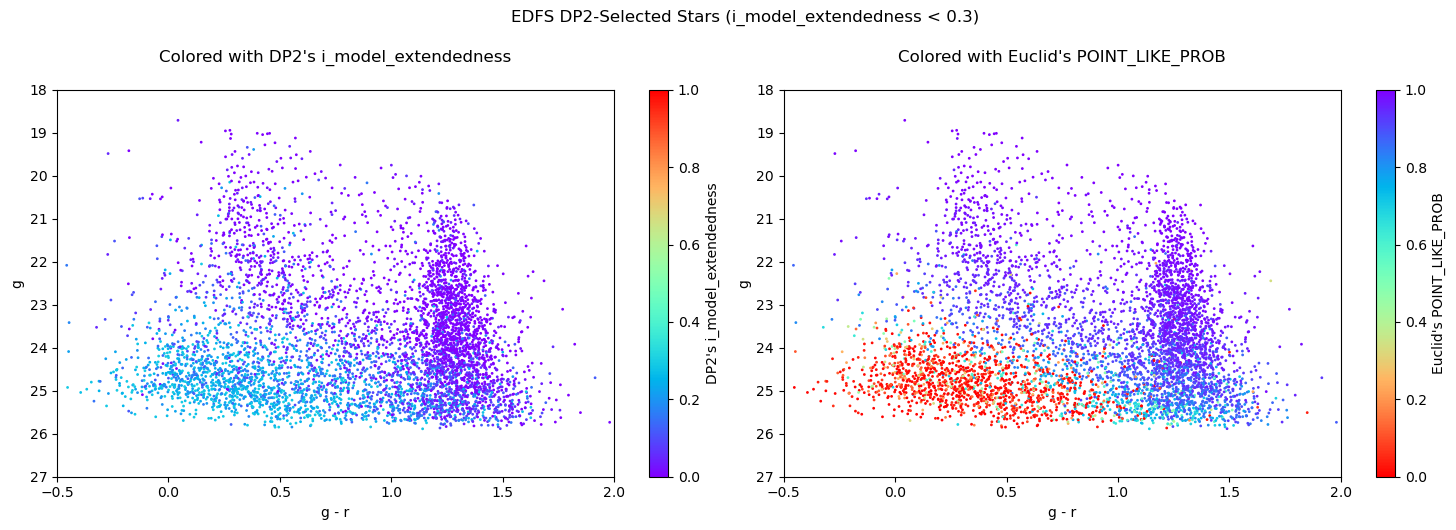

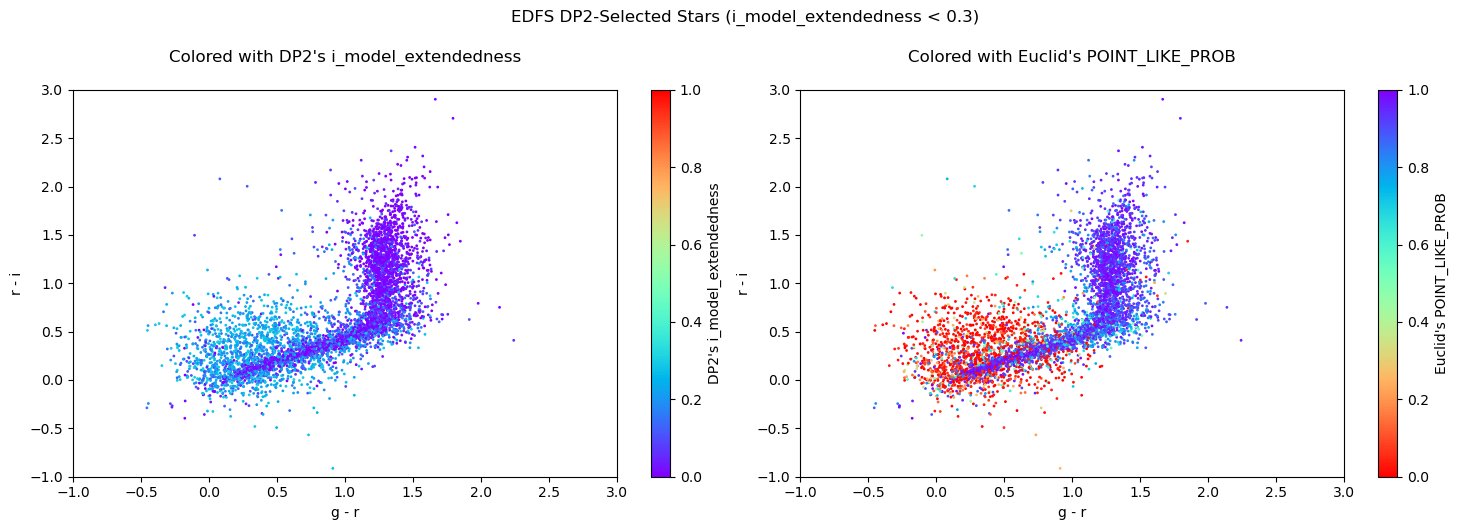

In [32]:
imodel_stars = onetractedfs.apply_mask((onetractedfs.data['i_model_extendedness'] < 0.3))
#print(imodel_stars.quality_cuts)
imodel_stars = imodel_stars.clean_data('','','g',[], snr=5)
print(imodel_stars.quality_cuts)

## color-mag g v g-r
fig, axes = plt.subplots(1,2, figsize=(15,5))
## coloring with Euclid morphology
color_magnitude(imodel_stars.data, 'g', 'r',
                imodel_stars.pointlikeprob, 'Euclid\'s POINT_LIKE_PROB', '_nolegend',
                "Colored with Euclid's POINT_LIKE_PROB", 
                ax = axes[1], histogram = False, colors = 'rainbow_r', x_lim = (-0.5,2), y_lim = (27,18))
## coloring with i_model_extendedness
color_magnitude(imodel_stars.data, 'g', 'r',
                imodel_stars.data['i_model_extendedness'], 'DP2\'s i_model_extendedness', '_nolegend',
                "Colored with DP2's i_model_extendedness", 
                ax = axes[0], histogram = False, colors = 'rainbow', x_lim = (-0.5,2), y_lim = (27,18))
title = fig.suptitle(f'{imodel_stars.field} {imodel_stars.survey.upper()}-Selected Stars (i_model_extendedness < 0.3)', 
                     y = 1.05)
fig.savefig(my_plotspath+'/colormag/imodelext_euclidcomp_dp2edfs.png', bbox_inches="tight", bbox_extra_artists=[title])

## color-color r-i vs g-r
fig, axes = plt.subplots(1,2, figsize=(15,5))
## coloring with Euclid morphology
color_color([('g',imodel_stars.g_mag),('r',imodel_stars.r_mag),('r',imodel_stars.r_mag),('i',imodel_stars.i_mag)],
            imodel_stars.pointlikeprob, 'Euclid\'s POINT_LIKE_PROB',
            '_nolegend', "Colored with Euclid's POINT_LIKE_PROB",
            colors = 'rainbow_r',
            histogram = False, ax = axes[1],
            x_lim = (-1,3), y_lim = (-1,3))
color_color([('g',imodel_stars.g_mag),('r',imodel_stars.r_mag),('r',imodel_stars.r_mag),('i',imodel_stars.i_mag)],
            imodel_stars.data['i_model_extendedness'], 'DP2\'s i_model_extendedness',
            '_nolegend', "Colored with DP2's i_model_extendedness",
            colors = 'rainbow',
            histogram = False, ax = axes[0],
            x_lim = (-1,3), y_lim = (-1,3))
title = fig.suptitle(f'{imodel_stars.field} {imodel_stars.survey.upper()}-Selected Stars (i_model_extendedness < 0.3)', 
                     y = 1.05)
fig.savefig(my_plotspath+'/colorcolor/imodelext_euclidcomp_dp2edfs.png', bbox_inches="tight", bbox_extra_artists=[title])

### refExtendedness

{'detect_isIsolated': 2, 'SPURIOUS_FLAG': 0, 'DET_QUALITY_FLAG': [0, 2, 0, 2, 512], 'LSST S/N': 'g > 5 r > 5 ', 'Euclid S/N': "[] > 5 ['VIS'] > 5 ", 'LSST per band flag': 'griz', 'FWHM': 3.0}


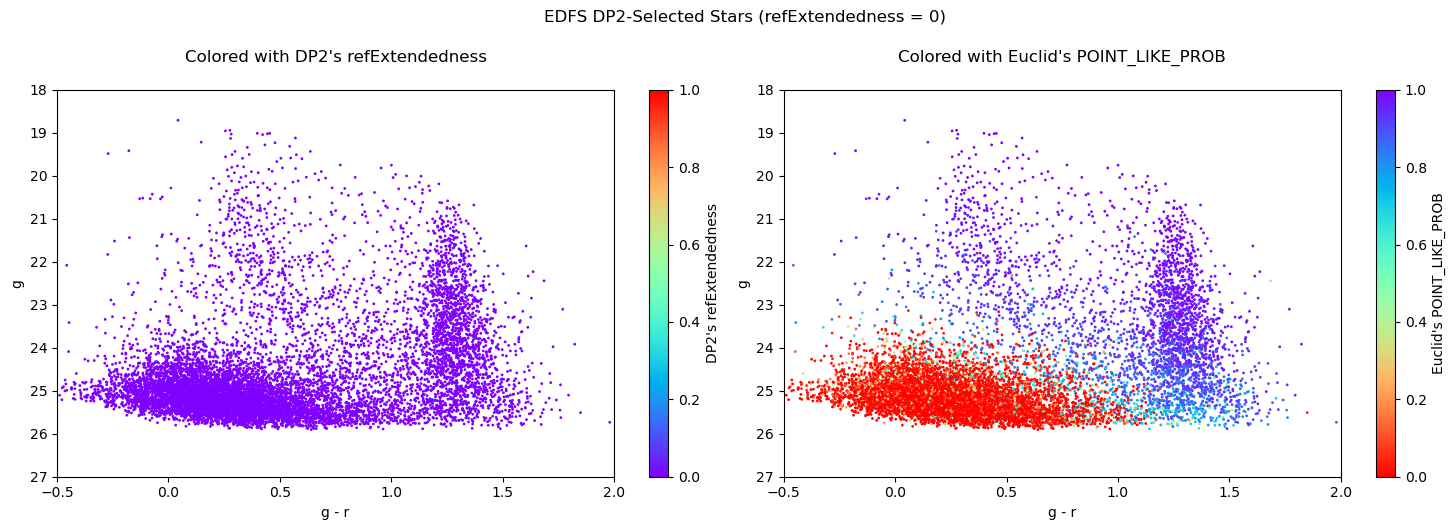

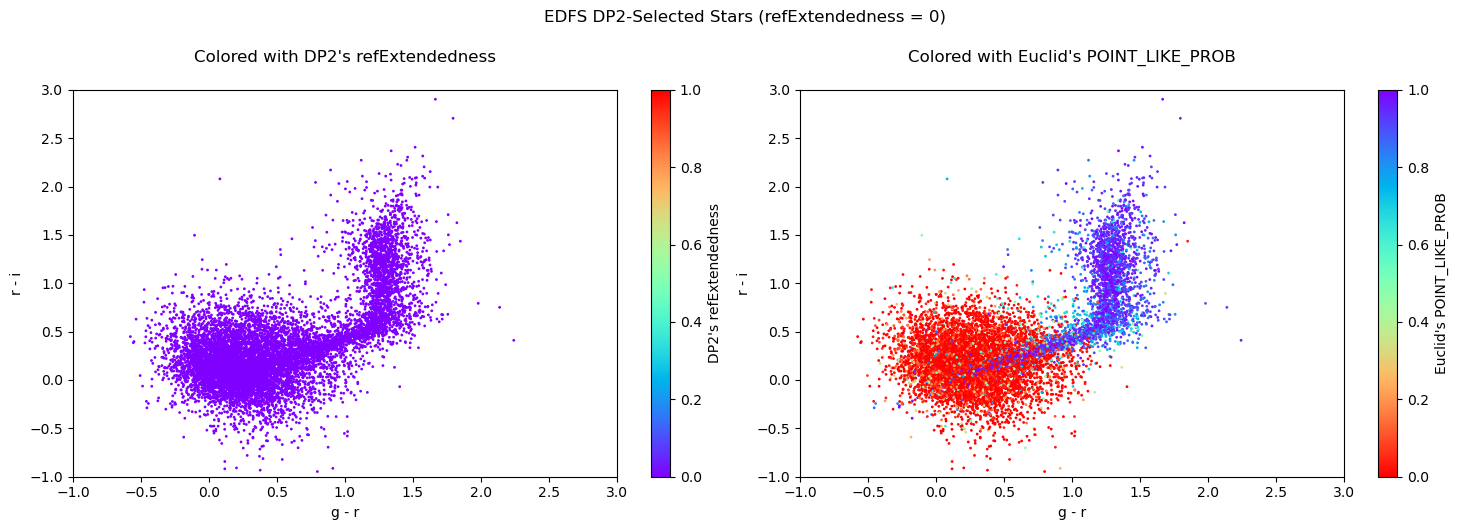

In [33]:
refext_stars = onetractedfs.apply_mask((onetractedfs.data['refExtendedness'] == 0))
refext_stars = refext_stars.clean_data('','','g',[], snr=5)
print(refext_stars.quality_cuts)

## color-mag g v g-r
fig, axes = plt.subplots(1,2, figsize=(15,5))
## coloring with Euclid morphology
color_magnitude(refext_stars.data, 'g', 'r',
                refext_stars.pointlikeprob, 'Euclid\'s POINT_LIKE_PROB', '_nolegend',
                "Colored with Euclid's POINT_LIKE_PROB", 
                ax = axes[1], histogram = False, colors = 'rainbow_r', x_lim = (-0.5,2), y_lim = (27,18))
## coloring with refextendedness, but that means nothing really cause they're all 0 (or, should be)
color_magnitude(refext_stars.data, 'g', 'r',
                refext_stars.data['refExtendedness'], 'DP2\'s refExtendedness', '_nolegend',
                "Colored with DP2's refExtendedness", 
                ax = axes[0], histogram = False, colors = 'rainbow', x_lim = (-0.5,2), y_lim = (27,18))
title = fig.suptitle(f'{refext_stars.field} {refext_stars.survey.upper()}-Selected Stars (refExtendedness = 0)', 
                     y = 1.05)
fig.savefig(my_plotspath+'/colormag/refext_euclidcomp_dp2edfs.png', bbox_inches="tight", bbox_extra_artists=[title])

## color-color r-i vs g-r
fig, axes = plt.subplots(1,2, figsize=(15,5))
## coloring with Euclid morphology
color_color([('g',refext_stars.g_mag),('r',refext_stars.r_mag),('r',refext_stars.r_mag),('i',refext_stars.i_mag)],
            refext_stars.pointlikeprob, 'Euclid\'s POINT_LIKE_PROB',
            '_nolegend', "Colored with Euclid's POINT_LIKE_PROB",
            colors = 'rainbow_r',
            histogram = False, ax = axes[1],
            x_lim = (-1,3), y_lim = (-1,3))
## again, uselessly coloring with refextendedness
color_color([('g',refext_stars.g_mag),('r',refext_stars.r_mag),('r',refext_stars.r_mag),('i',refext_stars.i_mag)],
            refext_stars.data['refExtendedness'], 'DP2\'s refExtendedness',
            '_nolegend', "Colored with DP2's refExtendedness",
            colors = 'rainbow',
            histogram = False, ax = axes[0],
            x_lim = (-1,3), y_lim = (-1,3))
title = fig.suptitle(f'{refext_stars.field} {refext_stars.survey.upper()}-Selected Stars (refExtendedness = 0)', 
                     y = 1.05)
fig.savefig(my_plotspath+'/colorcolor/refext_euclidcomp_dp2edfs.png', bbox_inches="tight", 
            bbox_extra_artists=[title])

### i_flux_ratio classifier with c = 1.2

{'detect_isIsolated': 2, 'SPURIOUS_FLAG': 0, 'DET_QUALITY_FLAG': [0, 2, 0, 2, 512], 'LSST S/N': 'g > 5 r > 5 ', 'Euclid S/N': "[] > 5 ['VIS'] > 5 ", 'LSST per band flag': 'griz', 'FWHM': 3.0}


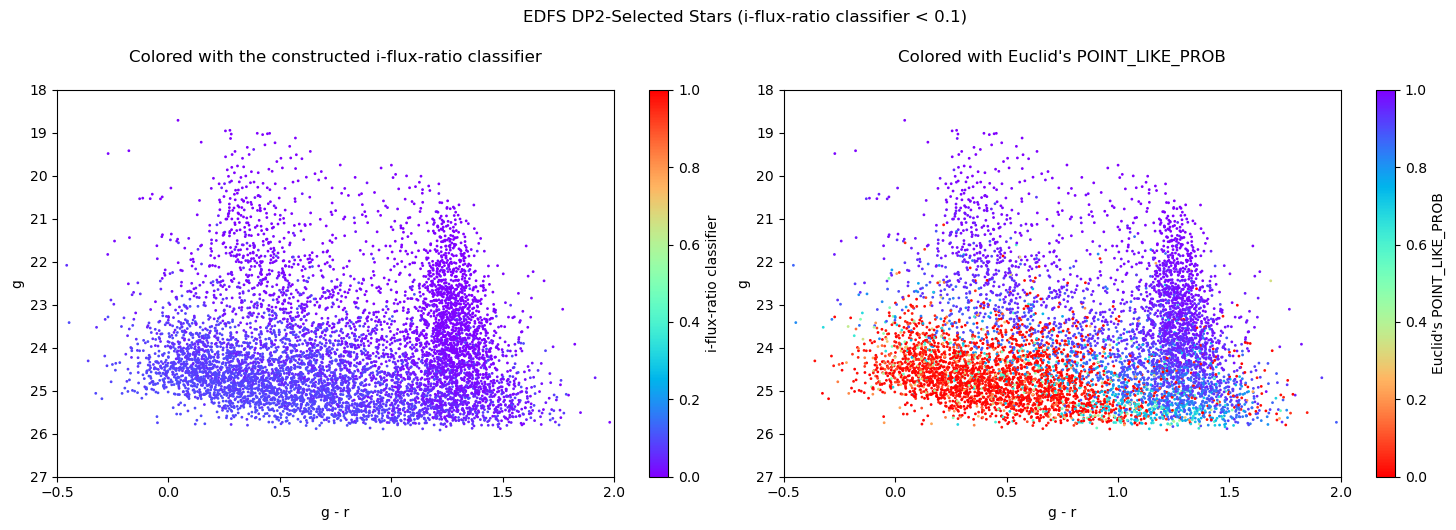

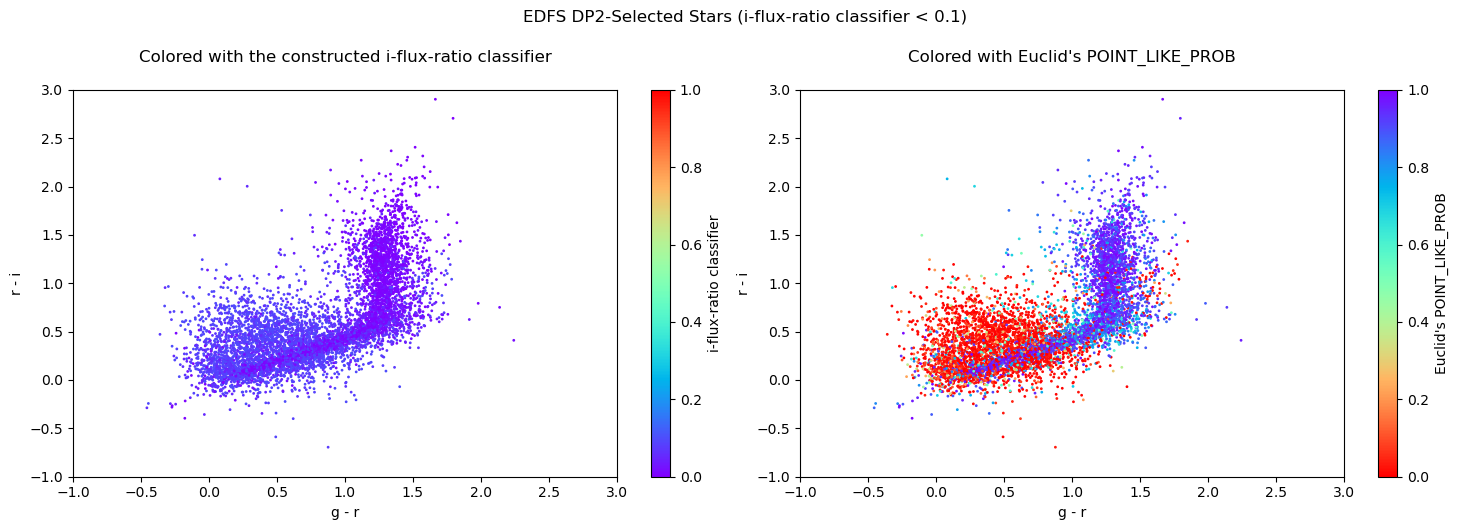

In [34]:
ifluxrat_stars = onetractedfs.apply_mask((flux_ratio_classifier(1.2,onetractedfs.data,'i') < 0.1))
ifluxrat_stars = ifluxrat_stars.clean_data('','','g',[], snr=5)
print(ifluxrat_stars.quality_cuts)

## color-mag g v g-r
fig, axes = plt.subplots(1,2, figsize=(15,5))
## coloring with Euclid morphology
color_magnitude(ifluxrat_stars.data, 'g', 'r',
                ifluxrat_stars.pointlikeprob, 'Euclid\'s POINT_LIKE_PROB', '_nolegend',
                "Colored with Euclid's POINT_LIKE_PROB", 
                ax = axes[1], histogram = False, colors = 'rainbow_r', x_lim = (-0.5,2), y_lim = (27,18))
## coloring with i_flux_ratio
color_magnitude(ifluxrat_stars.data, 'g', 'r',
                flux_ratio_classifier(1.2,ifluxrat_stars.data,'i'), 'i-flux-ratio classifier', '_nolegend',
                "Colored with the constructed i-flux-ratio classifier", 
                ax = axes[0], histogram = False, colors = 'rainbow', x_lim = (-0.5,2), y_lim = (27,18))
title = fig.suptitle(f'{ifluxrat_stars.field} {ifluxrat_stars.survey.upper()}-Selected Stars (i-flux-ratio classifier < 0.1)', 
                     y = 1.05)
fig.savefig(my_plotspath+'/colormag/ifluxrat_euclidcomp_dp2edfs.png', bbox_inches="tight", bbox_extra_artists=[title])

## color-color r-i vs g-r
fig, axes = plt.subplots(1,2, figsize=(15,5))
## coloring with Euclid morphology
color_color([('g',ifluxrat_stars.g_mag),('r',ifluxrat_stars.r_mag),('r',ifluxrat_stars.r_mag),('i',ifluxrat_stars.i_mag)],
            ifluxrat_stars.pointlikeprob, 'Euclid\'s POINT_LIKE_PROB',
            '_nolegend', "Colored with Euclid's POINT_LIKE_PROB",
            colors = 'rainbow_r',
            histogram = False, ax = axes[1],
            x_lim = (-1,3), y_lim = (-1,3))
## coloring with i_flux_ratio
color_color([('g',ifluxrat_stars.g_mag),('r',ifluxrat_stars.r_mag),('r',ifluxrat_stars.r_mag),('i',ifluxrat_stars.i_mag)],
            flux_ratio_classifier(1.2,ifluxrat_stars.data,'i'), 'i-flux-ratio classifier',
            '_nolegend', "Colored with the constructed i-flux-ratio classifier",
            colors = 'rainbow',
            histogram = False, ax = axes[0],
            x_lim = (-1,3), y_lim = (-1,3))
title = fig.suptitle(f'{ifluxrat_stars.field} {ifluxrat_stars.survey.upper()}-Selected Stars (i-flux-ratio classifier < 0.1)', 
                     y = 1.05)
fig.savefig(my_plotspath+'/colorcolor/ifluxrat_euclidcomp_dp2edfs.png', bbox_inches="tight", 
            bbox_extra_artists=[title])

### all objects

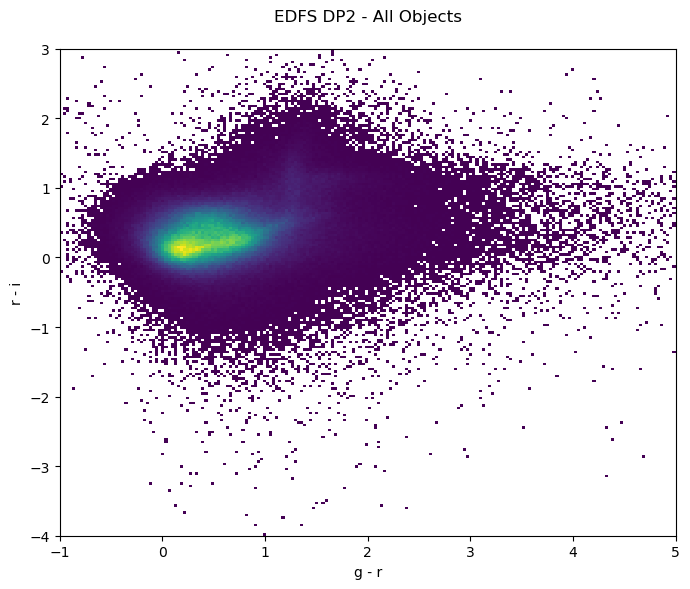

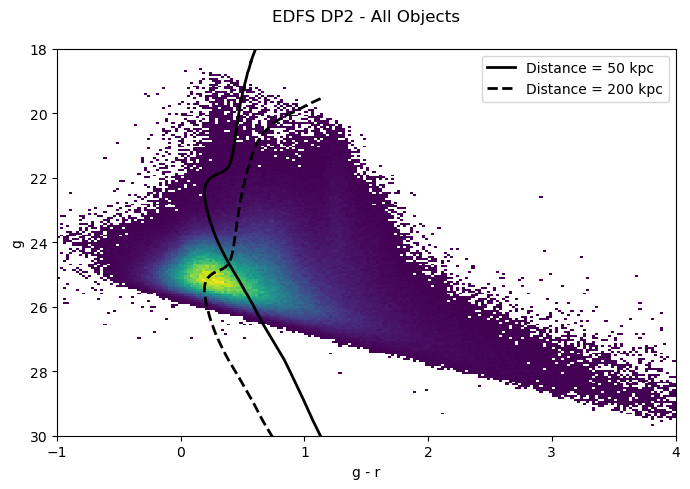

In [35]:
color_color([('g',EDFS_cleaned.g_mag),('r',EDFS_cleaned.r_mag),('r',EDFS_cleaned.r_mag),('i',EDFS_cleaned.i_mag)],
            None, None,
            '_nolegend',
            f'{EDFS_cleaned.field} {EDFS_cleaned.survey.upper()} - All Objects',
            histogram = True, colors = 'viridis',
            x_lim = (-1,5), y_lim = (-4,3),
            save = True, plots_path = my_plotspath, 
            filename=f'allobjects_{EDFS_cleaned.field.lower()}_{EDFS_cleaned.survey.lower()}')

color_magnitude(EDFS_cleaned.data,
                'g', 'r',
                None, None,
                '_nolegend',
                f'{field} {survey.upper()} - All Objects', 
                histogram = True, colors = 'viridis')
len(EDFS_cleaned.data)
distance = np.array([50, 200])#500]), 5000]) # kpc
distance_modulus = coordinate_tools.distanceToDistanceModulus(distance)

ls = ['-','--','-.']

for i in range(len(distance_modulus)):
    iso = isochrone.Isochrone(
            age=12.0,
            metallicity=0.0002,
            distance_modulus=distance_modulus[i],
            survey= 'mixed',
            band_1= 'g',
            band_2= 'r')
        
    index = np.min(np.where(iso.stage >= iso.hb_stage)[0])
    plt.plot(iso.mag_1[0:index] - iso.mag_2[0:index], iso.mag_1[0:index] + distance_modulus[i],
            c = 'k', label = f'Distance = {distance[i]} kpc', ls = ls[i], lw = 2)
plt.legend()
plt.savefig(my_plotspath + f'/colormag/allobjects+isochrones_{EDFS_cleaned.field.lower()}_{EDFS_cleaned.survey.lower()}')

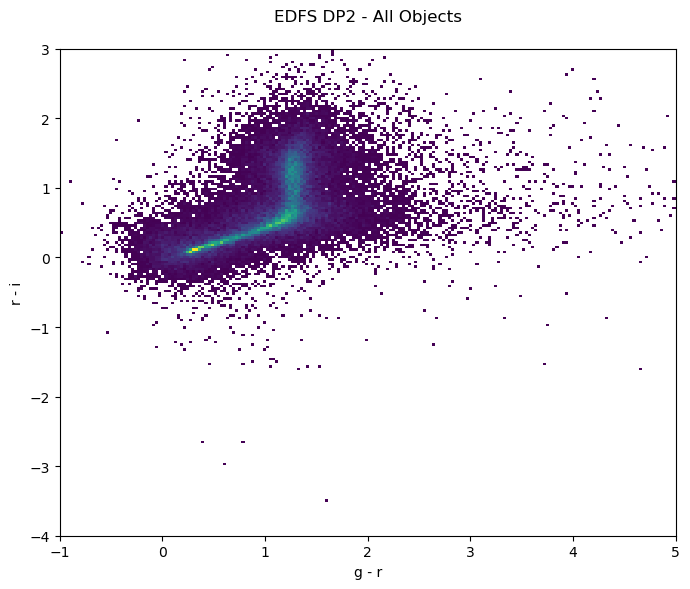

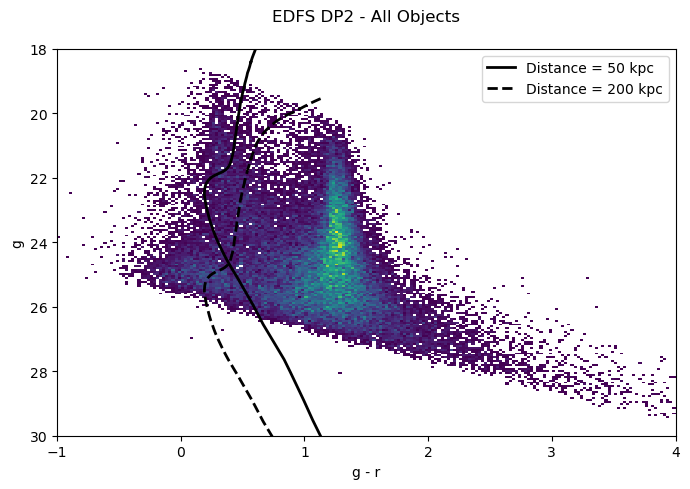

In [36]:
zerjal_mask, DF_zerjal = EDFS_cleaned.Zerjal_cut()
color_color([('g',DF_zerjal.g_mag),('r',DF_zerjal.r_mag),('r',DF_zerjal.r_mag),('i',DF_zerjal.i_mag)],
            None, None,
            '_nolegend',
            f'{DF_zerjal.field} {DF_zerjal.survey.upper()} - All Objects',
            histogram = True, colors = 'viridis',
            x_lim = (-1,5), y_lim = (-4,3),
            save = True, plots_path = my_plotspath, 
            filename=f'zerjalcut_{DF_zerjal.field.lower()}_{DF_zerjal.survey.lower()}')

color_magnitude(DF_zerjal.data,
                'g', 'r',
                None, None,
                '_nolegend',
                f'{field} {survey.upper()} - All Objects', 
                histogram = True, colors = 'viridis')
len(EDFS_cleaned.data)
distance = np.array([50, 200])#500]), 5000]) # kpc
distance_modulus = coordinate_tools.distanceToDistanceModulus(distance)

ls = ['-','--','-.']

for i in range(len(distance_modulus)):
    iso = isochrone.Isochrone(
            age=12.0,
            metallicity=0.0002,
            distance_modulus=distance_modulus[i],
            survey= 'mixed',
            band_1= 'g',
            band_2= 'r')
        
    index = np.min(np.where(iso.stage >= iso.hb_stage)[0])
    plt.plot(iso.mag_1[0:index] - iso.mag_2[0:index], iso.mag_1[0:index] + distance_modulus[i],
            c = 'k', label = f'Distance = {distance[i]} kpc', ls = ls[i], lw = 2)
plt.legend()
plt.savefig(my_plotspath+f'/colormag/zerjalcut+isochrones_{DF_zerjal.field.lower()}_{DF_zerjal.survey.lower()}')

#### NIR + Optical Color Mag attempt

In [37]:
'''
stars = DFsnr.apply_mask((DFsnr.r_mag - DFsnr.z_mag > 1.3) & (DFsnr.J_mag - DFsnr.H_mag < 0.15) & (DFsnr.J_mag - DFsnr.H_mag > -0.15))
plt.title(f'{DFsnr.field}')
plt.scatter(DFsnr.r_mag - DFsnr.z_mag, DFsnr.J_mag - DFsnr.H_mag, s = 1, c=DFsnr.pointlikeprob, label = 'All objects')
plt.scatter(stars.r_mag - stars.z_mag, stars.J_mag - stars.H_mag, s = 1, color = 'r', label = 'Stellar cut')
plt.xlabel('r - z')
plt.ylabel('J - H')
plt.ylim(-1,1)
plt.colorbar(label='POINT_LIKE_PROB')
plt.legend()
plt.show()

plt.scatter(stars.i_mag, stars.mumax_minus_mag, s = 1, color='c')
plt.show()
'''

"\nstars = DFsnr.apply_mask((DFsnr.r_mag - DFsnr.z_mag > 1.3) & (DFsnr.J_mag - DFsnr.H_mag < 0.15) & (DFsnr.J_mag - DFsnr.H_mag > -0.15))\nplt.title(f'{DFsnr.field}')\nplt.scatter(DFsnr.r_mag - DFsnr.z_mag, DFsnr.J_mag - DFsnr.H_mag, s = 1, c=DFsnr.pointlikeprob, label = 'All objects')\nplt.scatter(stars.r_mag - stars.z_mag, stars.J_mag - stars.H_mag, s = 1, color = 'r', label = 'Stellar cut')\nplt.xlabel('r - z')\nplt.ylabel('J - H')\nplt.ylim(-1,1)\nplt.colorbar(label='POINT_LIKE_PROB')\nplt.legend()\nplt.show()\n\nplt.scatter(stars.i_mag, stars.mumax_minus_mag, s = 1, color='c')\nplt.show()\n"

In [38]:
snr = 15
ECDFS_snr = ECDFS.clean_data('gz',['VIS','H'],'gz',['VIS','H'],snr=snr,flags=True,det_qual_flags=[0,2,512])
ECDFS_snr.quality_cuts

{'detect_isIsolated': True,
 'SPURIOUS_FLAG': 0,
 'DET_QUALITY_FLAG': [0, 2, 512],
 'LSST S/N': 'gz > 15 ',
 'Euclid S/N': "['VIS', 'H'] > 15 ",
 'LSST per band flag': 'gz',
 'FWHM': 1.5}

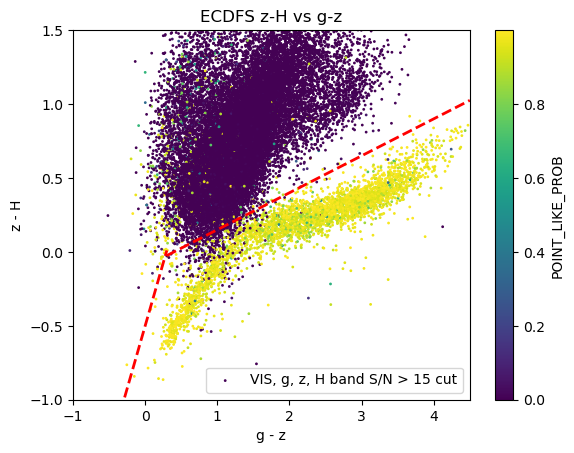

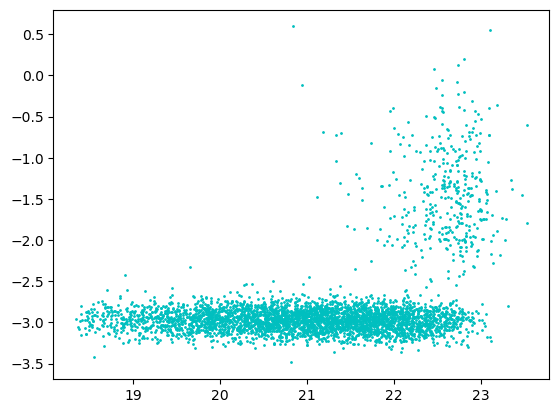

In [39]:
#DF = DF.apply_mask((DF.pointlikeprob > 0.4))

plt.title(f'{ECDFS_snr.field} z-H vs g-z')
plt.scatter(ECDFS_snr.g_mag - ECDFS_snr.z_mag, 
            ECDFS_snr.z_mag - ECDFS_snr.H_mag, 
            s = 1, c=ECDFS_snr.pointlikeprob, label = f'VIS, g, z, H band S/N > {snr} cut')

gz1 = np.linspace(-1,0.3)
gz2 = np.linspace(0.3,4.5)
plt.plot(gz1, -.5 + 1.7*gz1, 'r--', lw = 2)
plt.plot(gz2, -0.1 + 0.25*gz2, 'r--', lw = 2)
colormask1 = (ECDFS_snr.z_mag - ECDFS_snr.H_mag < (-.5 + 1.7*(ECDFS_snr.g_mag - ECDFS_snr.z_mag))) & ((ECDFS_snr.g_mag - ECDFS_snr.z_mag) <= 0.3) & ((ECDFS_snr.g_mag - ECDFS_snr.z_mag) > -1) 
colormask2 = (ECDFS_snr.z_mag - ECDFS_snr.H_mag < (-0.1 + 0.25*(ECDFS_snr.g_mag - ECDFS_snr.z_mag))) & ((ECDFS_snr.g_mag - ECDFS_snr.z_mag) < 4.5) & ((ECDFS_snr.g_mag - ECDFS_snr.z_mag) >= 0.3) 
colormask = colormask1 | colormask2
colorcolor_stars = ECDFS_snr.apply_mask(colormask)
#plt.scatter(colorcolor_stars.g_mag - colorcolor_stars.z_mag, 
#            colorcolor_stars.z_mag - colorcolor_stars.H_mag, s = 1, color = 'r', label = 'Stellar cut')

plt.xlabel('g - z')
plt.ylabel('z - H')
plt.ylim(-1,1.5)
plt.xlim(-1,4.5)
plt.colorbar(label='POINT_LIKE_PROB')
plt.legend()
plt.savefig(my_plotspath + f'/colorcolor/zHgz_{ECDFS_snr.field.lower()}_{ECDFS_snr.survey.lower()}')
plt.show()

plt.scatter(colorcolor_stars.i_mag, colorcolor_stars.mumax_minus_mag, s = 1, color='c')
plt.show()

In [40]:
snr = 5
ECDFS_lesssnr = ECDFS.clean_data('gz',['VIS','H'],'gz',['VIS','H'],snr=snr,flags=True,det_qual_flags=[0,2,512])
ECDFS_lesssnr.quality_cuts

{'detect_isIsolated': True,
 'SPURIOUS_FLAG': 0,
 'DET_QUALITY_FLAG': [0, 2, 512],
 'LSST S/N': 'gz > 5 ',
 'Euclid S/N': "['VIS', 'H'] > 5 ",
 'LSST per band flag': 'gz',
 'FWHM': 1.5}

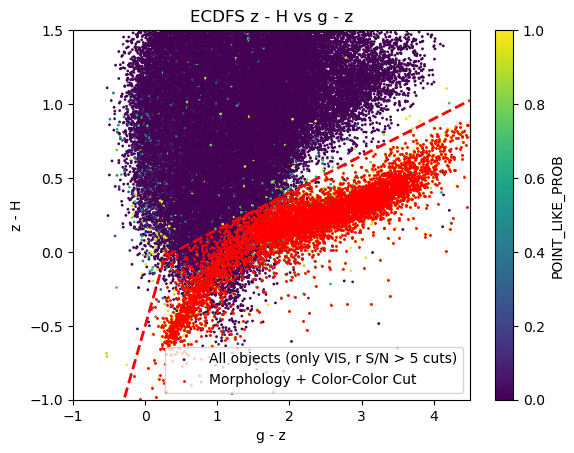

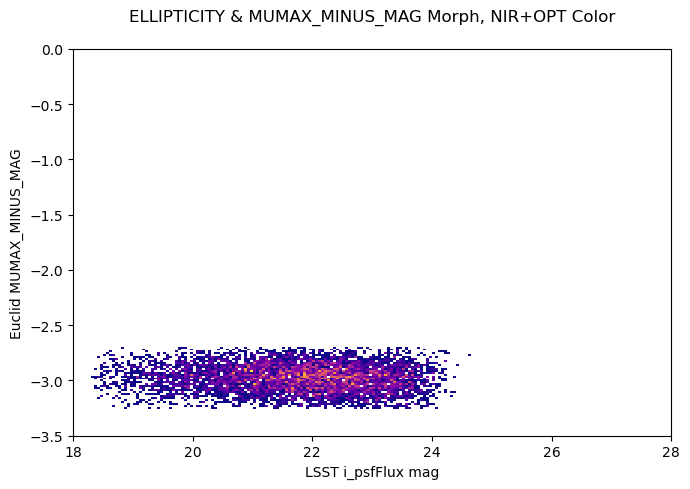

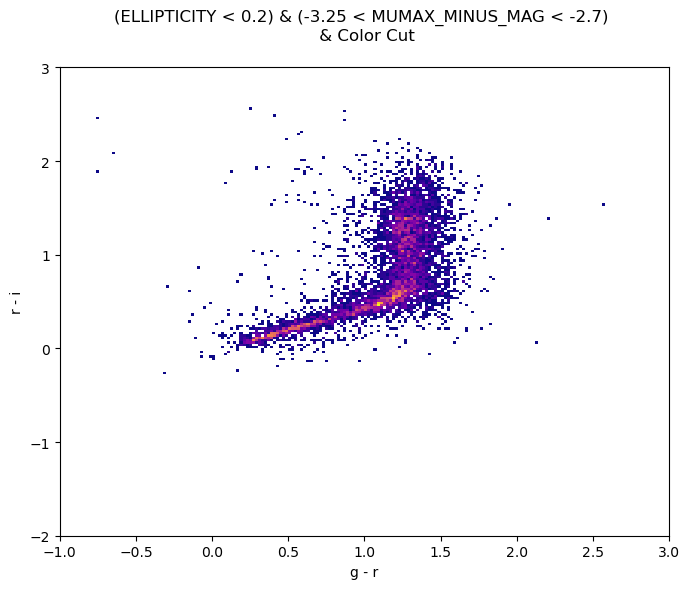

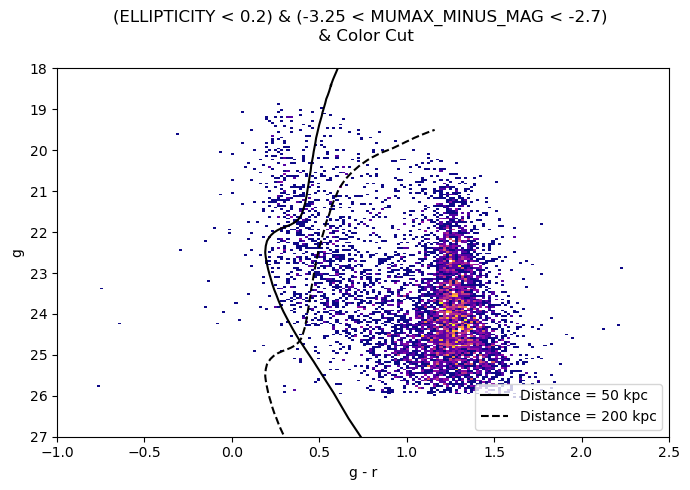

In [45]:
zerjal_mask, DF_zerjal = ECDFS_lesssnr.Zerjal_cut()
colormask1 = (ECDFS_lesssnr.z_mag - ECDFS_lesssnr.H_mag < (-.5 + 1.7*(ECDFS_lesssnr.g_mag - ECDFS_lesssnr.z_mag))) & ((ECDFS_lesssnr.g_mag - ECDFS_lesssnr.z_mag) <= 0.3) & ((ECDFS_lesssnr.g_mag - ECDFS_lesssnr.z_mag) > -1) 
colormask2 = (ECDFS_lesssnr.z_mag - ECDFS_lesssnr.H_mag < (-0.1 + 0.25*(ECDFS_lesssnr.g_mag - ECDFS_lesssnr.z_mag))) & ((ECDFS_lesssnr.g_mag - ECDFS_lesssnr.z_mag) < 4.5) & ((ECDFS_lesssnr.g_mag - ECDFS_lesssnr.z_mag) >= 0.3) 
colormask = colormask1 | colormask2
morph_n_color_mask = zerjal_mask & colormask

morph_n_color_stars = ECDFS_lesssnr.apply_mask(morph_n_color_mask)

gz1 = np.linspace(-1,0.3)
gz2 = np.linspace(0.3,4.5)
plt.plot(gz1, -.5 + 1.7*gz1, 'r--', lw = 2)
plt.plot(gz2, -0.1 + 0.25*gz2, 'r--', lw = 2)

plt.scatter(ECDFS_lesssnr.g_mag - ECDFS_lesssnr.z_mag, ECDFS_lesssnr.z_mag - ECDFS_lesssnr.H_mag, s = 1, c = ECDFS_lesssnr.pointlikeprob, label = 'All objects (only VIS, r S/N > 5 cuts)')
plt.scatter(morph_n_color_stars.g_mag - morph_n_color_stars.z_mag, 
            morph_n_color_stars.z_mag - morph_n_color_stars.H_mag, 
            s = 1, color = 'r', label = 'Morphology + Color-Color Cut')
plt.xlabel('g - z')
plt.ylabel('z - H')
plt.title(f'{morph_n_color_stars.field} z - H vs g - z')
plt.ylim(-1,1.5)
plt.xlim(-1,4.5)
plt.colorbar(label='POINT_LIKE_PROB')
plt.legend()
plt.savefig(my_plotspath + f'/colorcolor/zHgz_morphncolor_{ECDFS_lesssnr.field.lower()}_{ECDFS_lesssnr.survey.lower()}')
plt.show()

star_gal_sep(morph_n_color_stars.data, 'MUMAX_MINUS_MAG', 
             None, None, '_nolegend', 
             'ELLIPTICITY & MUMAX_MINUS_MAG Morph, NIR+OPT Color', 
             histogram = True, colors = 'plasma',
             y_lim=(-3.5, 0),save=True,plots_path = my_plotspath, 
            filename=f'zerjalcolorcolorcut_{morph_n_color_stars.field.lower()}_{morph_n_color_stars.survey.lower()}')

color_color([('g',morph_n_color_stars.g_mag),('r',morph_n_color_stars.r_mag),
             ('r',morph_n_color_stars.r_mag),('i',morph_n_color_stars.i_mag)],
            None, None,
            '_nolegend',
            '(ELLIPTICITY < 0.2) & (-3.25 < MUMAX_MINUS_MAG < -2.7) \n & Color Cut',
            histogram = True, colors = 'plasma',
            x_lim = (-1,3), y_lim = (-2,3),
            save = True, plots_path = my_plotspath, 
            filename=f'zerjalcolorcolorcut_{morph_n_color_stars.field.lower()}_{morph_n_color_stars.survey.lower()}')
color_magnitude(morph_n_color_stars.data,
                'g', 'r',
                None, None,
                '_nolegend',
                '(ELLIPTICITY < 0.2) & (-3.25 < MUMAX_MINUS_MAG < -2.7) \n & Color Cut', 
                histogram = True, colors = 'plasma', x_lim = (-1,2.5), y_lim = (27,18))
distance = np.array([50, 200])#500]), 5000]) # kpc
distance_modulus = coordinate_tools.distanceToDistanceModulus(distance)

ls = ['-','--','-.']

for i in range(len(distance_modulus)):
    iso = isochrone.Isochrone(
            age=12.0,
            metallicity=0.0002,
            distance_modulus=distance_modulus[i],
            survey= 'mixed',
            band_1= 'g',
            band_2= 'r')
        
    index = np.min(np.where(iso.stage >= iso.hb_stage)[0])
    plt.plot(iso.mag_1[0:index] - iso.mag_2[0:index], iso.mag_1[0:index] + distance_modulus[i],
            c = 'k', label = f'Distance = {distance[i]} kpc', ls = ls[i])
plt.legend(loc='lower right')
plt.savefig(my_plotspath + f'/colormag/zerjalcolorcolor+isochrones_{morph_n_color_stars.field.lower()}_{morph_n_color_stars.survey.lower()}')

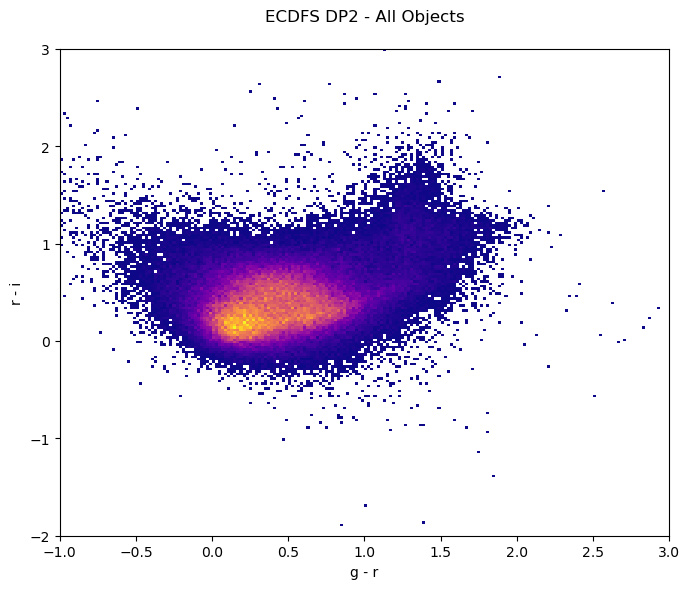

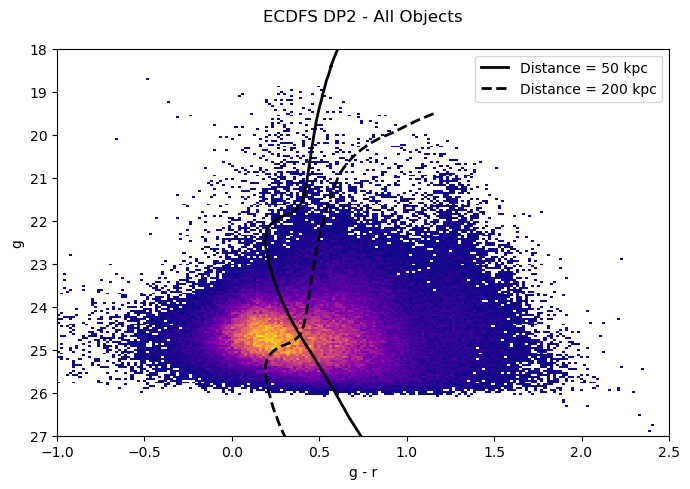

In [46]:
color_color([('g',ECDFS_lesssnr.g_mag),('r',ECDFS_lesssnr.r_mag),('r',ECDFS_lesssnr.r_mag),('i',ECDFS_lesssnr.i_mag)],
            None, None,
            '_nolegend',
            f'{ECDFS_lesssnr.field} {ECDFS_lesssnr.survey.upper()} - All Objects',
            histogram = True, colors = 'plasma',
            x_lim = (-1,3), y_lim = (-2,3),
            save = True, plots_path = my_plotspath, 
            filename=f'allobjects_gzHVISsnrcuts_{ECDFS_lesssnr.field.lower()}_{ECDFS_lesssnr.survey.lower()}')

color_magnitude(ECDFS_lesssnr.data,
                'g', 'r',
                None, None,
                '_nolegend',
                f'{ECDFS_lesssnr.field} {ECDFS_lesssnr.survey.upper()} - All Objects', 
                histogram = True, colors = 'plasma', x_lim = (-1,2.5), y_lim = (27,18))
distance = np.array([50, 200])#500]), 5000]) # kpc
distance_modulus = coordinate_tools.distanceToDistanceModulus(distance)

ls = ['-','--','-.']

for i in range(len(distance_modulus)):
    iso = isochrone.Isochrone(
            age=12.0,
            metallicity=0.0002,
            distance_modulus=distance_modulus[i],
            survey= 'mixed',
            band_1= 'g',
            band_2= 'r')
        
    index = np.min(np.where(iso.stage >= iso.hb_stage)[0])
    plt.plot(iso.mag_1[0:index] - iso.mag_2[0:index], iso.mag_1[0:index] + distance_modulus[i],
            c = 'k', label = f'Distance = {distance[i]} kpc', ls = ls[i], lw = 2)
plt.legend()
plt.savefig(my_plotspath + f'/colormag/allobjects+isochrones_gzHVISsnrcuts_{ECDFS_lesssnr.field.lower()}_{ECDFS_lesssnr.survey.lower()}')

In [ ]:
#to match peter's plot use H band for 158 and Y for 106

band1 = DF.g_mag
band2 = DF.H_mag

distance = np.array([50, 500])#, 5000]) # kpc
distance_modulus = coordinate_tools.distanceToDistanceModulus(distance)

fig, ax = plt.subplots(1,1, figsize=(6,6))
ls = ['-','--','-.']

for i in range(len(distance_modulus)):
    iso = isochrone.Isochrone(
            age=12.0,
            metallicity=0.0002,
            distance_modulus=distance_modulus[i],
            survey= 'mixed',
            band_1= 'g',
            band_2= 'H')
    
    #print(iso.band_1, iso.band_2)
    
    index = np.min(np.where(iso.stage >= iso.hb_stage)[0])
    ax.plot(iso.mag_1[0:index] - iso.mag_2[0:index], iso.mag_1[0:index] + distance_modulus[i],
            c = 'k', label = f'Distance = {distance[i]} kpc', ls = ls[i])
    #ax.plot(iso.mag_1[index:] - iso.mag_2[index:], iso.mag_1[index:] + distance_modulus[i],
    #        c = 'k', ls = ls[i])
    
plt.scatter(band1 - band2, band1,
            s = 1)
ax.set(title = f'{field} All Objects', 
       xlabel = 'g - H', ylabel = 'g', ylim = (24.2,18), xlim = (-0.5,3))
ax.legend()
plt.savefig(my_plotspath + f'colormag/g_h+isochrones_{DF.field.lower()}_{DF.survey.lower()}.png')

#this looks incorrect so.... idk

In [ ]:
quality_mask = (DF.g_mag.notna()) & (DF.H_mag.notna())
gh_DF = DF.apply_mask(quality_mask)
df_stars = gh_DF.Zerjal_cut()[1]
band1 = df_stars.g_mag
band2 = df_stars.H_mag

distance = np.array([50])#, 500])#, 5000]) # kpc
distance_modulus = coordinate_tools.distanceToDistanceModulus(distance)

fig, ax = plt.subplots(1,1, figsize=(6,6))
ls = ['-','--','-.']

for i in range(len(distance_modulus)):
    iso = isochrone.Isochrone(
            age=12.0,
            metallicity=0.0002,
            distance_modulus=distance_modulus[i],
            survey= 'mixed',
            band_1= 'g',
            band_2= 'H')
    
    #print(iso.band_1, iso.band_2)
    
    index = np.min(np.where(iso.stage >= iso.hb_stage)[0])
    ax.plot(iso.mag_1[0:index] - iso.mag_2[0:index], iso.mag_1[0:index] + distance_modulus[i],
            c = 'k', label = f'Distance = {distance[i]} kpc', ls = ls[i])
    #ax.plot(iso.mag_1[index:] - iso.mag_2[index:], iso.mag_1[index:] + distance_modulus[i],
    #        c = 'k', ls = ls[i])
    
plt.scatter(band1 - band2, band1,
            s = 1, label = 'Euclid-Labeled Stars')
ax.set(title = f'{df_stars.field} Stars', 
       xlabel = 'g - H', ylabel = 'g')
ax.legend()
plt.savefig(my_plotspath + f'colormag/g_h+isochrones_stars_{df_stars.field.lower()}_{df_stars.survey.lower()}.png')

#this looks incorrect so.... idk

#### More classifier evaluation

Classifiers tried:
- square addition: $\sqrt(\rm{g_{sizeext}^2 + r_{sizeext}^2 + i_{sizeext}^2})$, not good
- average: \frac{\rm{(g_{sizeext} + r_{sizeext} + i_{sizeext})}}{3}, not good
- "des-like": (1 - i_flux_ratio) + \frac52*i_flux_ratio_err, promising
    - (1 - i_flux_ratio) + 1.2*i_flux_ratio_err, better
- some ML logisitic regression ones
nothing so far wildly out performing band_model_extendedness

In [ ]:
c = 1.2
t = 0.07
ecdfs_fluxratio = ECDFS.apply_mask((flux_ratio_classifier(c,ECDFS.data,'i')< t))
edfs_fluxratio = EDFS.apply_mask((flux_ratio_classifier(c,EDFS.data,'i')< t))
selection_label = f'1 - i_flux_ratio + {c}*i_flux_ratio_error < {t}'

fig, axes = plt.subplots(1,2, figsize = (10,5))
color_color([('g',ecdfs_fluxratio.g_mag),('r',ecdfs_fluxratio.r_mag),
             ('r',ecdfs_fluxratio.r_mag),('i',ecdfs_fluxratio.i_mag)],
            ecdfs_fluxratio.pointlikeprob, None, '_nolegend', 
            None,
            x_lim = (-1,4),
            ax = axes[0],)
color_color([('g',edfs_fluxratio.g_mag),('r',edfs_fluxratio.r_mag),
             ('r',edfs_fluxratio.r_mag),('i',edfs_fluxratio.i_mag)],
            edfs_fluxratio.pointlikeprob, 'POINT_LIKE_PROB', '_nolegend', 
            None,
            x_lim = (-1,4),
            ax = axes[1],)
plt.suptitle('ECDFS v EDFS ' + selection_label)
plt.tight_layout()
plt.savefig(my_plotspath + 
    f'colorcolor/fluxratio{c}lt{t}stars_{ecdfs_fluxratio.field.lower()}+{edfs_fluxratio.field.lower()}_{ecdfs_fluxratio.survey.lower()}.png')

In [ ]:
t = 0.1
ecdfs_iext = ECDFS.apply_mask((ECDFS.data['i_model_extendedness'] < t))
edfs_iext = EDFS.apply_mask((EDFS.data['i_model_extendedness'] < t))

fig, axes = plt.subplots(1,2, figsize = (10,5))
color_color([('g',ecdfs_iext.g_mag),('r',ecdfs_iext.r_mag),
             ('r',ecdfs_iext.r_mag),('i',ecdfs_iext.i_mag)],
            ecdfs_iext.pointlikeprob, None, '_nolegend', 
            None,
            x_lim = (-1,4),
            ax = axes[0],)
color_color([('g',edfs_iext.g_mag),('r',edfs_iext.r_mag),
             ('r',edfs_iext.r_mag),('i',edfs_iext.i_mag)],
            edfs_iext.pointlikeprob, 'POINT_LIKE_PROB', '_nolegend', 
            None,
            x_lim = (-1,4),
            ax = axes[1],)
plt.suptitle(f'ECDFS v EDFS i_model_extendedness < {t}')
plt.tight_layout()
plt.savefig(my_plotspath + 
    f'colorcolor/iextlt{t}stars_{ecdfs_iext.field.lower()}+{edfs_iext.field.lower()}_{edfs_iext.survey.lower()}.png')

## ROC Attempt: 
## **I WANT TO KNOW WHAT I WAS DOING WRONG HERE**

Now we want to compare some of these classifiers. A classical way of doing this is the True Positive Rate vs False Positive Rate graph also called Receiver Operating Characteristic (ROC) curve.

### Null hypothesis = not a star
- false positive - truly a galaxy, classified as a star- type 1 error (prob=alpha)
- true negative - truly a galaxy, classified as a galaxy - (prob=1-alpha)
- true positive - truly a star, classified a star - (prob=1-beta)(power of test)
- false negative - truly a star, classified a galaxy - type 2 error (prob=beta)

In [ ]:
#DES classifier = (1 - fluxratio) + c*fluxratio_err
c_arr = np.linspace(0.3,3,50)
c_column = c_arr[:,np.newaxis] #column matrix
i_flux_ratio_err_row = np.array(i_flux_ratio_err)[np.newaxis,:] #row matrix
_2nd_term = c_column*i_flux_ratio_err_row #every row is a classifier and every column is a star
_1st_term = np.ones(np.shape(_2nd_term)) - np.ones(c_column.shape) * np.array(i_flux_ratio)
classifier = _1st_term + _2nd_term
#every row is a new trial of classifier, every column is the same star
#might need to do a better job of "what euclid calls a star"
truth_arr = np.ones(c_column.shape) * np.array(merged_df['POINT_LIKE_PROB'] > 0.5)
    #True = star, False = galaxy

#true pos, both true = 3
#false neg, truth is true, lsst is false = 2
#false pos, truth is false, lsst is true = 1
#true neg, both false = 0

x_arr = np.linspace(0,.2,40) #x = cutoff
#results = {(x1,c1) : {true pos : , false neg : , false pos : , true neg : }, (x1,c2): ...}
results = {}
results_arr = np.empty((x_arr.shape[0], c_arr.shape[0], 4))
for i in range(len(x_arr)):
    lsst_star_test = classifier < x_arr[i] #True = star, False = galaxy
    mask = ~np.isnan(lsst_star_test)
    lsst_star_test_clean = lsst_star_test[mask]
    test = 2*truth_arr + lsst_star_test
    for j in range(c_arr.shape[0]): #may be a way to get rid of this for loop but i don't know it so
        row = test[j, :]
        #results[(x, c_arr[i][0])] = {
        #just keeping it consistent with the numbers so I don't get confused
        #true pos = 3, false neg = 2, false pos = 1, true neg = 0
        results_arr[i,j,3] = np.count_nonzero(row == 3)
        results_arr[i,j,2] = np.count_nonzero(row == 2)
        results_arr[i,j,1] =  np.count_nonzero(row == 1)
        results_arr[i,j,0] = np.count_nonzero(row == 0)
        #make it callable? https://numpy.org/doc/stable/user/basics.rec.html

norm = matplotlib.colors.Normalize(vmin=c_arr.min(), vmax=c_arr.max())
cmap = plt.get_cmap("jet", len(c_arr))
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
fig, axes = plt.subplots(3,1, figsize = (7,15))

for i in range(len(c_arr)):
    true_stars_num = np.sum(merged_df['POINT_LIKE_PROB']>0.5)
    true_galaxies_num = np.sum(merged_df['POINT_LIKE_PROB']<0.5)
    true_pos = results_arr[:,i,3]
    false_pos = results_arr[:,i,1]
    completeness_givenc = true_pos/true_stars_num #this is just numbers for each coefficient, not split up by magnitude bin
    contamination_givenc = false_pos/(true_pos + false_pos)
    mask = np.isfinite(completeness_givenc)
    contamination_givenc = contamination_givenc[mask]
    completeness_givenc = completeness_givenc[mask]
    if i == 0:
        axes[0].plot(x_arr, completeness_givenc, '-', c=cmap(i))#, label = "Completeness")
        axes[1].plot(x_arr, contamination_givenc, '--', c=cmap(i))#, label = "Contamination")
    else:
        axes[0].plot(x_arr, completeness_givenc, c=cmap(i), ls = '-')
        axes[1].plot(x_arr, contamination_givenc, c=cmap(i), ls = '--')
    axes[0].set(xlabel = "Threshold", ylabel = "Completeness/Efficiency Rate")
    axes[1].set(xlabel = "Threshold", ylabel = "Contamination Rate")

    axes[2].plot(contamination_givenc, completeness_givenc, c=cmap(i), ls = '-')
    axes[2].set(xlabel = "Contamination", ylabel = "Completeness")

fig.colorbar(sm, orientation = 'horizontal', ax = axes[2], pad = 0.2, label = "Coefficient")
#plt.savefig(my_plotspath + f'varying_coefs.png')
plt.show()

In [ ]:
# NOT SUPER USEFUL PLOTS

In [ ]:
for band in 'griz':
    ecdfs[f'{band}_psfminuscmodel'] = rubin_morphology(ecdfs,band)
    ecdfs[f'{band}_psfminuscmodel_err'] = rubin_morphology_err(ecdfs,band)
    
    df = ecdfs[ecdfs['POINT_LIKE_PROB']>0.2]
    
    f,ax = plt.subplots(1,1, figsize=(8,6))
    _=ax.scatter(df[f'{band}_psfminuscmodel'],df[f'{band}_psfminuscmodel_err'],c=df['POINT_LIKE_PROB'],cmap='viridis')
    ax.set(xlabel = f'{band} psf - cModel mag', 
           ylabel = f'{band} psf - cModel mag err',ylim=(0,0.15),xlim=(-0.2,.2))
    plt.colorbar(_,label='point like prob')

In [ ]:
for band in 'griz':
    ecdfs[f'{band}_flux_ratio'] = flux_ratio(ecdfs,band)
    ecdfs[f'{band}_flux_ratio_err'] = flux_ratio_err(ecdfs,band)
    
    df = ecdfs[ecdfs['POINT_LIKE_PROB']>0.2]
    
    f,ax = plt.subplots(1,1, figsize=(8,6))
    _=ax.scatter(df[f'{band}_flux_ratio'],df[f'{band}_flux_ratio_err'],c=df['POINT_LIKE_PROB'],cmap='viridis')
    ax.set(xlabel = f'{band} flux ratio', ylabel = f'{band} flux ratio err',ylim=(-.2,0.4),xlim=(0.2,1.2))
    plt.colorbar(_,label='point like prob')

Tried my hand at a simple machine learning to find optimal flux ratio v err, not quite sure it worked...

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import DecisionBoundaryDisplay

ecdfs['euclid_truth_sg'] = (ecdfs['POINT_LIKE_PROB'] > 0.5).astype(int)

def logistic_regression(df, feature1, feature2, truth_label):
    # 1. Generate sample data for two distinct populations
    mask = (df[feature1].notna())&(df[feature2].notna())&(df[truth_label].notna())
    X_clean = df[[feature1,feature2]][mask]
    y_clean = df[truth_label][mask]
    # 2. Fit the Best Fit Model (Logistic Regression)
    model = LogisticRegression()
    model.fit(X_clean, y_clean)
    
    weights = model.coef_[0]
    intercept = model.intercept_[0]
    print(f"Decision Boundary Equation: {weights[0]:.3f} * x_1 + {weights[1]:.3f} * x_2 + {intercept:.3f} = 0")
    
    # 3. Visualization
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot the decision boundary
    DecisionBoundaryDisplay.from_estimator(
        model, X_clean, response_method="predict",
        cmap=plt.cm.coolwarm, alpha=0.8, ax=ax, grid_resolution=250
    )
    
    # Plot the actual data points
    scatter = ax.scatter(X_clean.to_numpy()[:, 0], X_clean.to_numpy()[:, 1], c=y_clean, cmap=plt.cm.coolwarm, edgecolors='k')
    
    # Add labels and title
    ax.set(title = "Population Separation via Logistic Regression",
           xlabel = feature1, ylabel = feature2,
           xlim = (0,1.1), ylim =(0,1))
    
    # Show the plot
    plt.show()

logistic_regression(ecdfs, 'i_flux_ratio', 'i_flux_ratio_err', 'euclid_truth_sg')

logistic_regression(ecdfs, 'r_psfminuscmodel', 'r_psfminuscmodel_err', 'euclid_truth_sg')

In [ ]:
# OLD CODE BELOW - all should be contained in plotting_functions.py

In [ ]:
"""
def color_magnitude(star_df, euc_colors, euc_label, lsst_colors, lsst_label, starselector_name, save = False, file_num = ''):
    '''
    Plots color-magnitude diagram, g vs g-r
    Expected that star_df would be sorted from a certain stellar classifier
        (i.e. just the sources LSST would classify as stars), but then those
        sources are plotted with both Euclid and LSST classifier colors

    Parameters
    ----------
    star_df : pandas dataframe
        Dataframe of the sources classified as stars
    euc_colors : dataframe column
        Data to be used for subplot 1 colorbar
        Euclid stellar classifier data (e.g. 'POINT_LIKE_PROB')
    euc_label : string
        Subplot 1 colorbar label
        Name of Euclid star classifier
    lsst_colors : dataframe column
        Data to be used for subplot 2 colorbar
        LSST-based stellar classifier data (e.g. 'i_SizeExtendedness')
    lsst_label : string
        Subplot 2 colorbar label
        Name of LSST star classifier
    starselector_name : string
        The survey with which the star_df has been sorted
        (e.g. if sorting based on 'i_SizeExtendedness' from DP1, this argument should be DP1)
    save (optional) : default False
        If True the file will be saved
    file_num (optional) : default ''
        You can optionally add a number if you don't want to overwrite
        the file previously saved with same name
        (file titles have form 'colormag_{starselector_name}stars_{lsst_label}_selector_{file_num}')

    Returns
    -------
    Pretty plot
    '''

    fig, ax = plt.subplots(1,2, figsize=(18,7))

    g_mag = flux2mag(star_df["g_psfFlux"].values)
    r_mag = flux2mag(star_df["r_psfFlux"].values)

    _ = ax[0].scatter(g_mag - r_mag, g_mag,
                c=lsst_colors,
                s=10, cmap="jet")
    cbar1 = plt.colorbar(_)#, ticks=[0.48, 0.4, 0.3, 0.2, 0.1, 0.02])
    cbar1.ax.invert_yaxis()
    #cbar1.ax.set_yticklabels(['more \n extended', '0.4', '0.3', '0.2', '0.1', 'less \n extended'])
    cbar1.set_label(lsst_label)
    ax[0].set(xlabel='g - r', ylabel='g', xlim = (-1, 4),
              ylim = (30, 18), title=f'{starselector_name}-Selected \'Stars\' Photometry with DP2 Extendedness')

    _ = ax[1].scatter(g_mag - r_mag, g_mag,
                c=euc_colors,
                s=10, cmap="jet_r")
    cbar2 = plt.colorbar(_) #, ticks=[0.02, 0.2, 0.4, 0.6, 0.8, 0.98])
    #cbar2.ax.set_yticklabels(['more \n extended', '0.2', '0.4', '0.6', '0.8', 'less \n extended'])
    cbar2.set_label(euc_label)
    ax[1].set(xlabel='g - r', ylabel='g', xlim = (-1, 4),
              ylim = (30, 18), title=f'{starselector_name}-Selected \'Stars\' Photometry with Euclid Extendedness')

    plt.tight_layout()
    if save == True:
        plt.savefig(my_plotspath + f"colormag_{starselector_name}stars_{lsst_label}_selector_{file_num}.png")



def color_color(star_df, euc_colors, euc_label, lsst_label, starselector_name, save = False, file_num = ''):
    '''
    Plots color-color, r-i vs g-r for different magnitudes
    Expected that star_df would be sorted from an LSST-based stellar classifier
        Point of this plot is to show how LSST's classification changes as sources get fainter

    Parameters
    ----------
    star_df : pandas dataframe
        Dataframe of the sources LSST classifies as stars
    euc_colors : dataframe column
        Data to be used for colorbar
        Euclid stellar classifier data (e.g. 'POINT_LIKE_PROB')
    euc_label : string
        Colorbar label
        Name of Euclid star classifier
    lsst_label : string
        Name of LSST star classifier used for star_df
        Only affects file name
    starselector_name : string
        The survey with which the star_df has been sorted
        (for now will just be DP1, just allowing for flexibility as more LSST data released)
    save (optional) : default False
        If True the file will be saved
    file_num (optional) : default ''
        You can optionally add a number if you don't want to overwrite
        the file previously saved with same name
        (file titles have form 'colorcolor_{starselector_name}stars_{lsst_label}_selector_{file_num}')

    Returns
    -------
    Pretty plot
    '''

    fig, ax = plt.subplots(1,3, figsize=(20,6))
    plt.suptitle(f'{starselector_name} \'Stars\' Photometry', fontsize = 18)

    g_mag = flux2mag(star_df["g_psfFlux"].values)
    r_mag = flux2mag(star_df["r_psfFlux"].values)
    i_mag = flux2mag(star_df["i_psfFlux"].values)

    bright = {"r mag" : [], "g mag" : [], "i mag" : [], "ext" : []}
    middle = {"r mag" : [], "g mag" : [], "i mag" : [], "ext" : []}
    dim = {"r mag" : [], "g mag" : [], "i mag" : [], "ext" : []}

    for i in range(len(r_mag)):
        r_i = r_mag[i]
        if (r_i > 18) and (r_i < 22):
            bright["r mag"].append(r_i)
            bright["g mag"].append(g_mag[i])
            bright["i mag"].append(i_mag[i])
            bright["ext"].append(euc_colors.to_list()[i])
        elif (r_i > 22) and (r_i < 24):
            middle["r mag"].append(r_i)
            middle["g mag"].append(g_mag[i])
            middle["i mag"].append(i_mag[i])
            middle["ext"].append(euc_colors.to_list()[i])
        else:
            dim["r mag"].append(r_i)
            dim["g mag"].append(g_mag[i])
            dim["i mag"].append(i_mag[i])
            dim["ext"].append(euc_colors.to_list()[i])
    for dic in [bright, middle, dim]:
        for key in dic.keys():
            dic[key] = np.array(dic[key])

    _ = ax[0].scatter(bright["g mag"] - bright["r mag"], bright["r mag"] - bright["i mag"],
                c=bright["ext"],
                s=15, cmap="jet_r")
    _ = ax[1].scatter(middle["g mag"] - middle["r mag"], middle["r mag"] - middle["i mag"],
                c=middle["ext"],
                s=15, cmap="jet_r")
    _ = ax[2].scatter(dim["g mag"] - dim["r mag"], dim["r mag"] - dim["i mag"],
                c=dim["ext"],
                s=15, cmap="jet_r")
    plt.colorbar(_,label=euc_label)
    ax[0].set(ylabel='r - i', ylim = (-0.6,2),
              xlabel='g - r', xlim = (-0.6,2.5),
              title='r mag 20 - 22')
    ax[1].set(ylabel='r - i', ylim = (-0.6,2),
              xlabel='g - r', xlim = (-0.6,2.5),
              title='r mag 22 - 24')
    ax[2].set(ylabel='r - i', ylim = (-0.6,2),
              xlabel='g - r', xlim = (-0.6,2.5),
              title='r mag 24 - 26')
    plt.tight_layout()
    if save == True:
        plt.savefig(my_plotspath + f"colorcolor_{starselector_name}stars_{lsst_label}_selector_{file_num}.png")


def star_gal_sep(merged_df, colors1, label1, colors2, label2, surveyname, y_bounds, save = False, add_lines = False, file_num = ''):
    '''
    Plots color-color, r-i vs g-r for different magnitudes
    Expected that star_df would be sorted from an LSST-based stellar classifier
    Point of this plot is to show how LSST's classification changes as sources get fainter

    Parameters
    ----------
    merged_df : pandas dataframe
        Dataframe of all sources
    colors1 : dataframe column
        Data to be used for subplot 1 colorbar
    label1 : string
        Subplot 1 colorbar label
        If label1 and label2 are to be different,
        label 1 should be the one for which you want the file named
    colors2 : dataframe column
        Data to be used for subplot 2 colorbar
    label2 : string
        Subplot 2 colorbar label
    surveyname : string
        Survey from which i band photometry is being pulled
        (where merged_df is getting its i_psfFlux and i_cModelFlux)
    y_bounds : tuple of floats
        Argument for subplot 1's ylim
        Found it necessary to zoom and enhance on LSST selector
    save (optional) : default False
        If True the file will be saved
    file_num (optional) : default ''
        You can optionally add a number if you don't want to overwrite
        the file previously saved with same name
        (file titles have form 'star-gal-sep_{label1}_selector_{file_num}')

    Returns
    -------
    Pretty plot
    '''

    fig, ax = plt.subplots(1,2, figsize=(18,6))

    i_mag = flux2mag(merged_df["i_psfFlux"].values)
    i_mag_cmodel = flux2mag(merged_df["i_cModelFlux"].values)

    _=ax[0].scatter(i_mag,
                i_mag - i_mag_cmodel,
                c = colors1,
                s = 10, cmap = "viridis_r")
    ax[0].set(xlabel = f'{surveyname} i_psfFlux', ylabel = f'{surveyname} i psf - cmodel mag', ylim = y_bounds)
    plt.colorbar(_,label = label1)
    _=ax[1].scatter(i_mag,
                merged_df['MUMAX_MINUS_MAG'],
                c = colors2,
                s = 10, cmap = 'viridis_r')
    plt.colorbar(_,label = label2)
    ax[1].set(xlabel = f'{surveyname} i_psfFlux', ylabel = "Euclid mu_max - mag")
    if add_lines == True:
        ax[1].plot(i_mag, (-0.07*i_mag)-1.2, label = "Cutoff Attempt")
    plt.tight_layout()
    if save == True:
        plt.savefig(my_plotspath + f'star-gal-sep_{label1}_selector_{file_num}.png')
"""